# Whole-OTC geometry and Bayes factors

Standalone. The setup cell loads the harmonized CSVs directly and ports `load_harmonized` from `final_figures.ipynb`, so nothing here depends on that notebook being run first.


In [2]:
# ─── Setup: loads from source, independent of final_figures.ipynb ─────────
# Ports load_harmonized and the age merge so this notebook stands alone.
# Cohort of record: 36 controls, 12 LH-intact, 12 RH-intact.

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

REPO = Path('/user_data/csimmon2/git_repos/sym_pt')
D_LIU = REPO / 'D_liu'
SUB_INFO = REPO / 'sub_info.csv'
UNIVAR_SQRT = D_LIU / 'univariate_v1_harmonized_sqrt.csv'
RSA_HARM = D_LIU / 'rsa_v1_harmonized.csv'
MNI_CSV = D_LIU / 'peak_coords_mni.csv'
FIG_DIR = REPO / 'C_results' / 'figures' / 'whole_otc_bayes'
FIG_DIR.mkdir(parents=True, exist_ok=True)

EXCLUDE = ['sub-017', 'sub-091', 'sub-095', 'sub-096', 'sub-027', 'sub-084']
EXCLUDE_SES = [('sub-108', 2)]
AGE_CAP = 23

# age lookup from sub_info.csv. The column name varies between snapshots, so
# it is detected rather than assumed; if detection fails the age cap is skipped
# and that is printed loudly rather than passing silently.
_si = pd.read_csv(SUB_INFO)
_AGE_COL = next((c for c in _si.columns
                 if c.lower() in ('age', 'age_at_scan', 'scan_age')), None)
if _AGE_COL is None:
    _num = [c for c in _si.columns
            if pd.api.types.is_numeric_dtype(_si[c])
            and _si[c].between(5, 60).mean() > 0.8]
    _AGE_COL = _num[0] if _num else None
print('sub_info columns:', list(_si.columns))
print('age column detected:', _AGE_COL)


def _merge_age(d):
    if _AGE_COL is None:
        d['age'] = np.nan
        return d
    a = (_si.groupby('subject_id')[_AGE_COL].min()
         if 'subject_id' in _si.columns else None)
    if a is None:
        d['age'] = np.nan
        return d
    return d.merge(a.rename('age'), left_on='subject_id', right_index=True,
                   how='left')


def load_harmonized(path, label, collapse_pairs=False, drop_negative=None,
                    age_cap=None, intact_only=True):
    """EXCLUDE + EXCLUDE_SES applied, controls -> first session, OTC -> last.
    Returns (controls, patients). Ported from final_figures.ipynb."""
    d = pd.read_csv(path)
    d = d[d['group'].isin(['OTC', 'control'])]
    d = d[~d['subject_id'].isin(EXCLUDE)].copy()
    d['ses_num'] = pd.to_numeric(d['session'].astype(str).str.extract(
        r'(\d+)', expand=False), errors='coerce').astype('Int64')
    for bad_sub, bad_ses in EXCLUDE_SES:
        d = d[~((d['subject_id'] == bad_sub) & (d['ses_num'] == bad_ses))]

    if drop_negative is not None:
        n0 = len(d)
        d = d[d[drop_negative] >= 0]
        print(f'  {label}: dropped {n0 - len(d)} rows with {drop_negative} < 0')
    if collapse_pairs and 'pair' in d.columns:
        d = d.drop(columns=['pair', 'fisher_r']).drop_duplicates()
    if age_cap is not None:
        d = _merge_age(d)
        over = sorted(d.loc[d['age'] > age_cap, 'subject_id'].unique())
        miss = sorted(d.loc[d['age'].isna(), 'subject_id'].unique())
        print(f'  {label}: above cap {age_cap:g} -> {over or "none"} | '
              f'no age row -> {miss or "none"}')
        d = d[(d['age'] <= age_cap) | d['age'].isna()]

    status = d['status'] if 'status' in d.columns else d['group']
    ctrl = d[status == 'control'].copy()
    ctrl = ctrl[ctrl['ses_num'] ==
                ctrl.groupby('subject_id')['ses_num'].transform('min')]
    pt = d[d['group'] == 'OTC'].copy()
    pt = pt[pt['ses_num'] ==
            pt.groupby('subject_id')['ses_num'].transform('max')]
    if intact_only:
        pt = pt[pt['hemi'] == pt['intact_hemi'].map({'left': 'l',
                                                     'right': 'r'})]
    by = pt.groupby('intact_hemi')['subject_id'].nunique().to_dict()
    print(f'{label}: ctrl n={ctrl.subject_id.nunique()}  '
          f'pt n={pt.subject_id.nunique()}  {by}')
    return ctrl, pt


rsa_c_long, rsa_p_long = load_harmonized(RSA_HARM, 'rsa long (by pair)',
                                         age_cap=AGE_CAP)
peak_c, peak_p = load_harmonized(UNIVAR_SQRT, 'univariate peak_z',
                                 age_cap=AGE_CAP)
vox_c, vox_p = load_harmonized(UNIVAR_SQRT, 'univariate volume',
                               age_cap=AGE_CAP)
if MNI_CSV.exists():
    pk_c, pk_p = load_harmonized(MNI_CSV, 'peak coords (MNI)',
                                 collapse_pairs=True)
else:
    print('peak_coords_mni.csv not found; peak-location block unavailable')

assert peak_c.subject_id.nunique() == 36, peak_c.subject_id.nunique()
assert peak_p.subject_id.nunique() == 24, peak_p.subject_id.nunique()
print('\ncohort of record confirmed: 36 controls, 12 + 12 patients')


/home/csimmon2/anaconda3/envs/fmri/lib/python3.9/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


sub_info columns: ['sub', 'ses', 'age', 'sex', 'surgery_side', 'intact_hemi', 'group', 'code', 'pre_post']
age column detected: age
  rsa long (by pair): above cap 23 -> none | no age row -> ['sub-001', 'sub-004', 'sub-005', 'sub-008', 'sub-010', 'sub-016', 'sub-018', 'sub-021', 'sub-022', 'sub-023', 'sub-025', 'sub-026', 'sub-028', 'sub-029', 'sub-031', 'sub-034', 'sub-035', 'sub-036', 'sub-037', 'sub-038', 'sub-039', 'sub-040', 'sub-041', 'sub-043', 'sub-044', 'sub-052', 'sub-054', 'sub-057', 'sub-058', 'sub-059', 'sub-062', 'sub-064', 'sub-065', 'sub-066', 'sub-067', 'sub-068', 'sub-069', 'sub-071', 'sub-074', 'sub-075', 'sub-076', 'sub-077', 'sub-078', 'sub-079', 'sub-082', 'sub-083', 'sub-085', 'sub-087', 'sub-088', 'sub-089', 'sub-090', 'sub-092', 'sub-093', 'sub-094', 'sub-097', 'sub-098', 'sub-099', 'sub-101', 'sub-108', 'sub-109']
rsa long (by pair): ctrl n=36  pt n=24  {'left': 12, 'right': 12}
  univariate peak_z: above cap 23 -> none | no age row -> ['sub-001', 'sub-004', '

## Whole-OTC geometry
Six between-category similarities per hemisphere over the whole OTC parcel; chance baseline and side typicality.

In [3]:
# ─── Whole-OTC odRSM: is the agreement above chance, and is it side-specific? ─
# Source: H_RosenkeRSM/otc_rsm_persubject.csv
#
# Three parts.
#  1  CHANCE BASELINE. Every subject shares a common six-value profile (e.g.
#     house-word near -0.69 in everyone), so correlating profiles largely
#     recovers that shared shape and nothing falls near zero. The null shuffles
#     the six pair labels within each subject, which destroys the shared shape
#     while keeping each subject's own six numbers.
#  2  SIDE TYPICALITY, raw profiles. Per subject: mean agreement with
#     same-side controls minus mean agreement with opposite-side controls.
#     Positive = the subject's geometry is side-typical. Controls should be
#     positive; the question is whether patients are near zero.
#  3  SIDE TYPICALITY, grand-mean removed. The grand mean profile over all
#     subjects is subtracted first, so agreement reflects shared DEVIATION from
#     the common shape rather than the shape itself.
# Same-subject pairs are always dropped, so a control's left profile is never
# correlated with its own right profile.

RSM_CSV_CH = REPO / 'H_RosenkeRSM' / 'otc_rsm_persubject.csv'
NPERM_CH   = 10000
rng_ch     = np.random.default_rng(42)

ch = pd.read_csv(RSM_CSV_CH)
PAIRS_CH = [c for c in ch.columns if '-' in c]
assert len(PAIRS_CH) == 6, PAIRS_CH
ch['set'] = np.where(
    ch.group == 'control', 'ctl_' + ch.hemi.str.upper(),
    np.where(ch.intact_hemi == ch.hemi.map({'l': 'left', 'r': 'right'}),
             'pt_' + ch.hemi.str.upper(), 'drop'))
ch = ch[ch['set'] != 'drop'].reset_index(drop=True)
SETS_CH = ['ctl_L', 'pt_L', 'ctl_R', 'pt_R']
print('  ' + '   '.join(f'{s} {int((ch["set"] == s).sum())}' for s in SETS_CH))

M_CH    = ch[PAIRS_CH].to_numpy(float)
sid_ch  = ch['subject_id'].to_numpy()
set_ch  = ch['set'].to_numpy()
SAME_CH = sid_ch[:, None] == sid_ch[None, :]
IDX_CH  = {s: np.where(set_ch == s)[0] for s in SETS_CH}


def _zc(M):
    return (M - M.mean(1, keepdims=True)) / M.std(1, ddof=0, keepdims=True)


def _corr(M):
    Z = _zc(M)
    return Z @ Z.T / M.shape[1]


def _blk(C, i, j):
    b, keep = C[np.ix_(i, j)], ~SAME_CH[np.ix_(i, j)]
    return b[keep].mean()


def _perm1(a, b, n=NPERM_CH):
    a, b = np.asarray(a, float), np.asarray(b, float)
    obs = a.mean() - b.mean()
    pool, na, k = np.concatenate([a, b]), len(a), 0
    for _ in range(n):
        p = rng_ch.permutation(pool)
        if abs(p[:na].mean() - p[na:].mean()) >= abs(obs) - 1e-12:
            k += 1
    return obs, (k + 1) / (n + 1)


# ── 1. chance baseline ──────────────────────────────────────────────────────
C_RAW = _corr(M_CH)
off = ~SAME_CH & ~np.eye(len(M_CH), dtype=bool)
obs_all = C_RAW[off].mean()
null_all = np.empty(2000)
for b in range(2000):
    Ms = np.array([rng_ch.permutation(r) for r in M_CH])
    null_all[b] = _corr(Ms)[off].mean()
print('\n1. IS THE AGREEMENT ABOVE CHANCE')
print(f'   observed mean r over all between-subject pairs   {obs_all:+.3f}')
print(f'   null (six pair labels shuffled within subject)   {null_all.mean():+.3f} '
      f'[{np.percentile(null_all, 2.5):+.3f}, {np.percentile(null_all, 97.5):+.3f}]')
print(f'   p = {(np.sum(null_all >= obs_all) + 1) / 2001:.4f}')
print('   A null near -0.2 is expected: six values shuffled within subject are')
print('   still constrained to the same sum, so they anti-correlate slightly.')

# ── 2 & 3. side typicality ──────────────────────────────────────────────────
for tag, Mx in [('RAW PROFILES', M_CH),
                ('GRAND-MEAN REMOVED', M_CH - M_CH.mean(0, keepdims=True))]:
    C = _corr(Mx)
    typ = np.full(len(Mx), np.nan)
    for i in range(len(Mx)):
        same, opp = ('ctl_L', 'ctl_R') if set_ch[i].endswith('L') else ('ctl_R', 'ctl_L')
        typ[i] = _blk(C, [i], IDX_CH[same]) - _blk(C, [i], IDX_CH[opp])

    print(f'\n{"2" if tag == "RAW PROFILES" else "3"}. SIDE TYPICALITY — {tag}')
    print('   agreement with same-side controls minus opposite-side controls')
    print(f'   {"set":8s} {"n":>3s} {"mean":>8s} {"sd":>7s}')
    for s in SETS_CH:
        v = typ[IDX_CH[s]]
        print(f'   {s:8s} {len(v):3d} {v.mean():+8.3f} {v.std(ddof=1):7.3f}')
    for side in ('L', 'R'):
        d, p = _perm1(typ[IDX_CH['ctl_' + side]], typ[IDX_CH['pt_' + side]])
        print(f'   ctl_{side} vs pt_{side}:  diff {d:+.3f}  p = {p:.4f}'
              + ('  *' if p < .05 else ''))
    print(f'   4x4 agreement matrix under {tag.lower()}')
    print('              ' + ''.join(f'{s:>9s}' for s in SETS_CH))
    for a in SETS_CH:
        print(f'     {a:9s}' + ''.join(f'{_blk(C, IDX_CH[a], IDX_CH[b]):+9.3f}'
                                       for b in SETS_CH))
    if tag == 'RAW PROFILES':
        TYP_RAW_CH = typ.copy()
    else:
        TYP_GMR_CH = typ.copy()


  ctl_L 36   pt_L 12   ctl_R 36   pt_R 12

1. IS THE AGREEMENT ABOVE CHANCE
   observed mean r over all between-subject pairs   +0.575
   null (six pair labels shuffled within subject)   -0.000 [-0.009, +0.015]
   p = 0.0005
   A null near -0.2 is expected: six values shuffled within subject are
   still constrained to the same sum, so they anti-correlate slightly.

2. SIDE TYPICALITY — RAW PROFILES
   agreement with same-side controls minus opposite-side controls
   set        n     mean      sd
   ctl_L     36   +0.147   0.098
   pt_L      12   +0.002   0.217
   ctl_R     36   +0.050   0.160
   pt_R      12   -0.008   0.183
   ctl_L vs pt_L:  diff +0.145  p = 0.0021  *
   ctl_R vs pt_R:  diff +0.058  p = 0.2976
   4x4 agreement matrix under raw profiles
                  ctl_L     pt_L    ctl_R     pt_R
     ctl_L       +0.703   +0.521   +0.556   +0.572
     pt_L        +0.521   +0.419   +0.519   +0.508
     ctl_R       +0.556   +0.519   +0.606   +0.564
     pt_R        +0.572   +0.5

## Whole-OTC two-comparison figure
Controls' hemispheres versus patients' preserved hemispheres, profile-shape permutation.

a · controls: statistic = 0.0886, p = 0.00010
b · patients: statistic = 0.0059, p = 0.96940


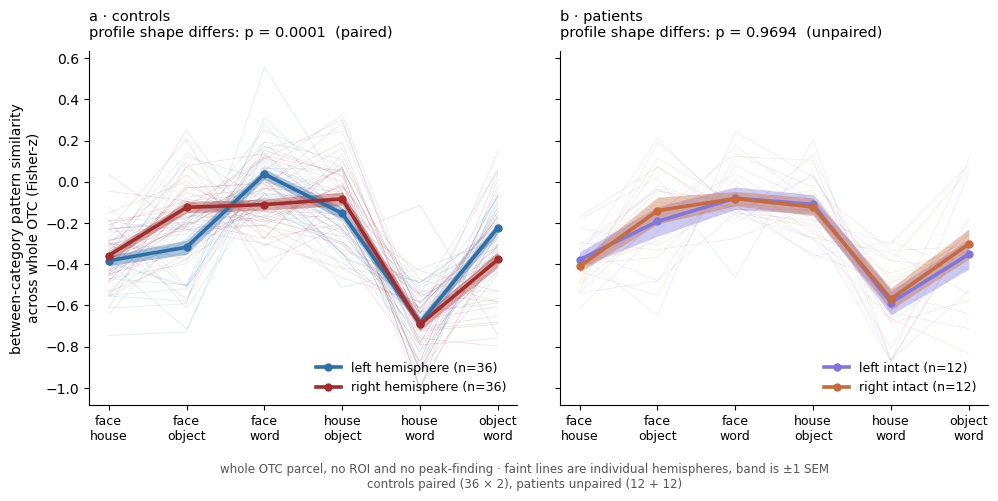

saved /user_data/csimmon2/git_repos/sym_pt/C_results/figures/whole_otc_bayes/otc_rsm_two_comparisons.png


In [4]:
# ─── Whole-OTC geometry: controls' hemispheres differ, patients' do not ─────
# Needs M_CH, IDX_CH, ch from the side-typicality cell.
# Source: H_RosenkeRSM/otc_rsm_persubject.csv
#
# Two comparisons, one panel each:
#   a  LH controls vs RH controls
#   b  LH-intact patients vs RH-intact patients
# Each hemisphere contributes six between-category pattern similarities over the
# whole OTC parcel. Group means with +/-1 SEM bands, individual hemispheres
# faint behind (Weber et al. 2026, Nat Hum Behav, Fig 4a-e).
#
# Test: the pair x group interaction from a per-comparison linear mixed model
# with subject as a random intercept, by joint Wald chi2 on the five interaction
# terms (df = 5) - the same test the manuscript uses for between-category
# similarity at the ROI level. Controls are paired (36 people, both
# hemispheres); patients are unpaired (12 + 12 different people).

PAIR_LBL = ['face\nhouse', 'face\nobject', 'face\nword',
            'house\nobject', 'house\nword', 'object\nword']
PAIRS_17 = [c for c in ch.columns if '-' in c]
CL17, CR17 = '#2f6fa8', '#a32d2d'
PL17, PR17 = '#7f77dd', '#c96a3a'


rng17 = np.random.default_rng(31)
NPERM17 = 10000


def _interaction(sa, sb, paired):
    """Does the SHAPE of the six-pair profile differ between two sets?

    Statistic: the six between-set mean differences with their own average
    removed, summed as squares. Removing the average makes the test insensitive
    to an overall level difference, so it tests the profile shape only - the
    permutation analogue of a pair x group interaction.

    Controls are paired, so the null is sign-flipping each subject's
    left-minus-right difference. Patients are unpaired, so the null is shuffling
    the group label.
    """
    A, B = M_CH[IDX_CH[sa]], M_CH[IDX_CH[sb]]

    def stat(d):
        return float(((d - d.mean()) ** 2).sum())

    if paired:
        ida = ch['subject_id'].to_numpy()[IDX_CH[sa]]
        idb = ch['subject_id'].to_numpy()[IDX_CH[sb]]
        A, B = A[np.argsort(ida)], B[np.argsort(idb)]
        D = A - B
        obs = stat(D.mean(0))
        null = np.array([stat((D * rng17.choice([-1, 1], len(D))[:, None]).mean(0))
                         for _ in range(NPERM17)])
    else:
        obs = stat(A.mean(0) - B.mean(0))
        pool, na = np.vstack([A, B]), len(A)
        null = np.empty(NPERM17)
        for b in range(NPERM17):
            p = rng17.permutation(len(pool))
            null[b] = stat(pool[p[:na]].mean(0) - pool[p[na:]].mean(0))
    return obs, (np.sum(null >= obs) + 1) / (NPERM17 + 1)


fig, axes = plt.subplots(1, 2, figsize=(11.6, 4.6), sharey=True,
                         gridspec_kw=dict(wspace=0.10))

for ax, (sa, sb, ca, cb, la, lb, ttl) in zip(axes, [
        ('ctl_L', 'ctl_R', CL17, CR17, 'left hemisphere', 'right hemisphere',
         'a \u00b7 controls'),
        ('pt_L', 'pt_R', PL17, PR17, 'left intact', 'right intact',
         'b \u00b7 patients')]):
    for s, col, lab in ((sa, ca, la), (sb, cb, lb)):
        X = M_CH[IDX_CH[s]]
        m, se = X.mean(0), X.std(0, ddof=1) / np.sqrt(len(X))
        for row in X:
            ax.plot(range(6), row, color=col, lw=.5, alpha=.16, zorder=1)
        ax.fill_between(range(6), m - se, m + se, color=col, alpha=.38, lw=0, zorder=2)
        ax.plot(range(6), m, color=col, lw=2.6, marker='o', ms=5,
                label=f'{lab} (n={len(X)})', zorder=3)
    obs, pv = _interaction(sa, sb, paired=sa.startswith('ctl'))
    ax.set_title(f'{ttl}\nprofile shape differs: p = {pv:.4f}'
                 + ('  (paired)' if sa.startswith('ctl') else '  (unpaired)'),
                 loc='left', fontsize=10.5, pad=10)
    ax.set_xticks(range(6)); ax.set_xticklabels(PAIR_LBL, fontsize=9)
    ax.legend(fontsize=9, frameon=False, loc='lower right')
    for sp in ('top', 'right'):
        ax.spines[sp].set_visible(False)
    print(f'{ttl}: statistic = {obs:.4f}, p = {pv:.5f}')

axes[0].set_ylabel('between-category pattern similarity\nacross whole OTC (Fisher-z)',
                   fontsize=10)
fig.text(0.5, -0.07,
         'whole OTC parcel, no ROI and no peak-finding \u00b7 faint lines are individual '
         'hemispheres, band is \u00b11 SEM\ncontrols paired (36 \u00d7 2), patients unpaired '
         '(12 + 12)', ha='center', fontsize=8.5, color='#555')
out17 = FIG_DIR / 'otc_rsm_two_comparisons.png'
plt.savefig(out17, dpi=300, bbox_inches='tight')
plt.show()
print('saved', out17)


a · controls: statistic = 0.0886, p = 0.00010
b · patients: statistic = 0.0059, p = 0.96940


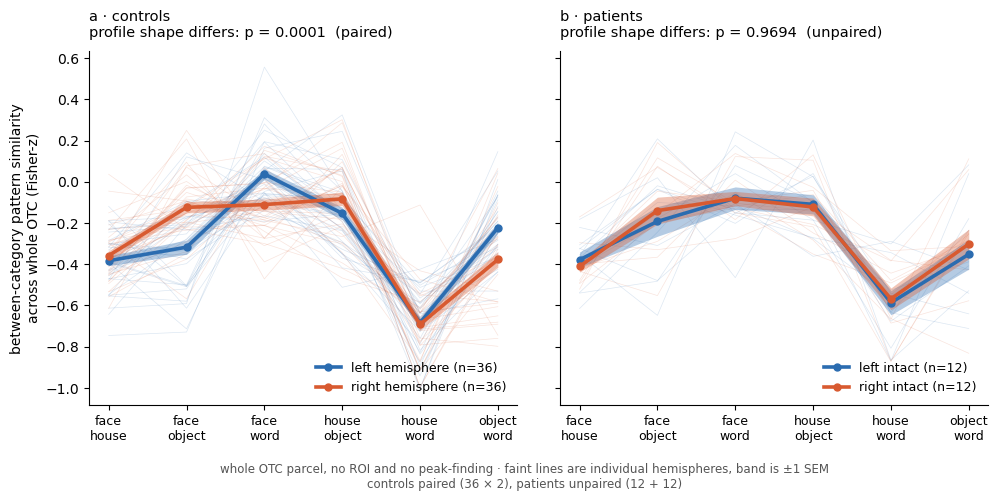

saved /user_data/csimmon2/git_repos/sym_pt/C_results/figures/whole_otc_bayes/otc_rsm_two_comparisons.png


In [17]:
# ─── Whole-OTC geometry: controls' hemispheres differ, patients' do not ─────
# Needs M_CH, IDX_CH, ch from the side-typicality cell.
# Source: H_RosenkeRSM/otc_rsm_persubject.csv

PAIR_LBL = ['face\nhouse', 'face\nobject', 'face\nword',
            'house\nobject', 'house\nword', 'object\nword']
PAIRS_17 = [c for c in ch.columns if '-' in c]

# ─── COLOR PALETTE (Directly from Figure 1 Variables) ───────────────────────
C_SCAN = "#2B6CB0"  # Steel Blue (Left hemisphere / LH-intact)
C_SURG = "#D85A30"  # Terracotta Orange (Right hemisphere / RH-intact)

CL17, CR17 = C_SCAN, C_SURG  # Controls: Left (Blue) vs Right (Orange)
PL17, PR17 = C_SCAN, C_SURG  # Patients: LH-intact (Blue) vs RH-intact (Orange)

rng17 = np.random.default_rng(31)
NPERM17 = 10000


def _interaction(sa, sb, paired):
    """Does the SHAPE of the six-pair profile differ between two sets?"""
    A, B = M_CH[IDX_CH[sa]], M_CH[IDX_CH[sb]]

    def stat(d):
        return float(((d - d.mean()) ** 2).sum())

    if paired:
        ida = ch['subject_id'].to_numpy()[IDX_CH[sa]]
        idb = ch['subject_id'].to_numpy()[IDX_CH[sb]]
        A, B = A[np.argsort(ida)], B[np.argsort(idb)]
        D = A - B
        obs = stat(D.mean(0))
        null = np.array([stat((D * rng17.choice([-1, 1], len(D))[:, None]).mean(0))
                         for _ in range(NPERM17)])
    else:
        obs = stat(A.mean(0) - B.mean(0))
        pool, na = np.vstack([A, B]), len(A)
        null = np.empty(NPERM17)
        for b in range(NPERM17):
            p = rng17.permutation(len(pool))
            null[b] = stat(pool[p[:na]].mean(0) - pool[p[na:]].mean(0))
    return obs, (np.sum(null >= obs) + 1) / (NPERM17 + 1)


fig, axes = plt.subplots(1, 2, figsize=(11.6, 4.6), sharey=True,
                         gridspec_kw=dict(wspace=0.10))

for ax, (sa, sb, ca, cb, la, lb, ttl) in zip(axes, [
        ('ctl_L', 'ctl_R', CL17, CR17, 'left hemisphere', 'right hemisphere',
         'a \u00b7 controls'),
        ('pt_L', 'pt_R', PL17, PR17, 'left intact', 'right intact',
         'b \u00b7 patients')]):
    for s, col, lab in ((sa, ca, la), (sb, cb, lb)):
        X = M_CH[IDX_CH[s]]
        m, se = X.mean(0), X.std(0, ddof=1) / np.sqrt(len(X))
        for row in X:
            ax.plot(range(6), row, color=col, lw=.5, alpha=.16, zorder=1)
        ax.fill_between(range(6), m - se, m + se, color=col, alpha=.35, lw=0, zorder=2)
        ax.plot(range(6), m, color=col, lw=2.6, marker='o', ms=5,
                label=f'{lab} (n={len(X)})', zorder=3)
    obs, pv = _interaction(sa, sb, paired=sa.startswith('ctl'))
    ax.set_title(f'{ttl}\nprofile shape differs: p = {pv:.4f}'
                 + ('  (paired)' if sa.startswith('ctl') else '  (unpaired)'),
                 loc='left', fontsize=10.5, pad=10)
    ax.set_xticks(range(6)); ax.set_xticklabels(PAIR_LBL, fontsize=9)
    ax.legend(fontsize=9, frameon=False, loc='lower right')
    for sp in ('top', 'right'):
        ax.spines[sp].set_visible(False)
    print(f'{ttl}: statistic = {obs:.4f}, p = {pv:.5f}')

axes[0].set_ylabel('between-category pattern similarity\nacross whole OTC (Fisher-z)',
                   fontsize=10)
fig.text(0.5, -0.07,
         'whole OTC parcel, no ROI and no peak-finding \u00b7 faint lines are individual '
         'hemispheres, band is \u00b11 SEM\ncontrols paired (36 \u00d7 2), patients unpaired '
         '(12 + 12)', ha='center', fontsize=8.5, color='#555')
out17 = FIG_DIR / 'otc_rsm_two_comparisons.png'
plt.savefig(out17, dpi=300, bbox_inches='tight')
plt.show()
print('saved', out17)

## Bayes factor functions

In [5]:
# ─── Bayes factors for the paper's nulls ────────────────────────────────────
# Two reusable functions plus a demonstration on the whole-OTC data.
#
#   bf10_jzs(...)     exact JZS default Bayes factor for one- and two-sample
#                     t tests (Rouder, Speckman, Sun, Morey & Iverson 2009,
#                     Psychon Bull Rev 16:225-237), r = 0.707.
#   bf_incl_bic(...)  Bayes factor for including an interaction, from the BIC
#                     approximation BF10 = exp((BIC_null - BIC_full) / 2)
#                     (Wagenmakers 2007, Psychon Bull Rev 14:779-804). This is
#                     an APPROXIMATION to the BF_incl that a Bayesian ANOVA
#                     returns; it uses subject fixed effects in place of a
#                     random intercept. Report it as such, or recompute with
#                     JASP / the BayesFactor package if an exact value is needed.
#
# Convention (Weber et al. 2026): BF10 < 1/3 is moderate evidence FOR the null,
# BF10 > 3 is moderate evidence against it, and 1/3 to 3 is inconclusive.
#
# To apply this to the manuscript's own nulls, point the same two functions at
# the harmonized per-subject files:
#   D_liu/rsa_v1_harmonized.csv             preferred- and between-category
#   D_liu/univariate_v1_harmonized_sqrt.csv peak selectivity, voxel counts
#   wta_percentages.csv                     WTA composition
# every patient-vs-patient contrast in those files is a two-group mean
# comparison, so bf10_jzs(..., paired=False) applies directly.

from scipy import integrate


def bf10_jzs(x, y=None, paired=False, r=0.707):
    """JZS default BF10. One sample vs 0, paired differences, or two groups."""
    x = np.asarray(x, float)
    if y is None:
        d = x
    elif paired:
        d = x - np.asarray(y, float)
    else:
        y = np.asarray(y, float)
        n1, n2 = len(x), len(y)
        sp = np.sqrt(((n1 - 1) * x.var(ddof=1) + (n2 - 1) * y.var(ddof=1))
                     / (n1 + n2 - 2))
        t = (x.mean() - y.mean()) / (sp * np.sqrt(1 / n1 + 1 / n2))
        n_eff, v = n1 * n2 / (n1 + n2), n1 + n2 - 2
        return _bf_from_t(t, n_eff, v, r)
    t = d.mean() / (d.std(ddof=1) / np.sqrt(len(d)))
    return _bf_from_t(t, len(d), len(d) - 1, r)


def _bf_from_t(t, n_eff, v, r):
    def num(g):
        return ((1 + n_eff * g) ** -0.5
                * (1 + t ** 2 / ((1 + n_eff * g) * v)) ** (-(v + 1) / 2)
                * (r ** 2 / 2) ** 0.5 / np.sqrt(np.pi) * g ** -1.5
                * np.exp(-r ** 2 / (2 * g)))
    return integrate.quad(num, 0, np.inf)[0] / (1 + t ** 2 / v) ** (-(v + 1) / 2)


def bf_incl_bic(y, factors, interaction):
    """BIC-approximated BF for including `interaction`, given a dict of
    categorical factors. Each factor is dummy-coded; `interaction` is a tuple of
    two factor names whose product terms are added to the full model."""
    def design(keys, inter=None):
        cols = [np.ones(len(y))]
        for k in keys:
            lv = np.unique(factors[k])[1:]
            cols += [(factors[k] == l).astype(float) for l in lv]
        if inter:
            a, b = inter
            for la in np.unique(factors[a])[1:]:
                for lb in np.unique(factors[b])[1:]:
                    cols.append(((factors[a] == la) & (factors[b] == lb)).astype(float))
        return np.column_stack(cols)

    def bic(X):
        beta, *_ = np.linalg.lstsq(X, y, rcond=None)
        rss = float(((y - X @ beta) ** 2).sum())
        n, k = len(y), np.linalg.matrix_rank(X)
        return n * np.log(rss / n) + k * np.log(n)

    keys = list(factors)
    return float(np.exp((bic(design(keys)) - bic(design(keys, interaction))) / 2))


def _label(bf):
    return ('moderate evidence FOR the null' if bf < 1 / 3 else
            'evidence AGAINST the null' if bf > 3 else 'inconclusive')


# ---- demonstration on the whole-OTC six-value profiles ---------------------
PAIRS_18 = [c for c in ch.columns if '-' in c]
sid_18 = ch['subject_id'].to_numpy()

print('1. PROFILE-SHAPE INTERACTION  (pair x group, BIC approximation)')
for sa, sb, lab, paired in [('ctl_L', 'ctl_R', 'LH ctrl vs RH ctrl', True),
                            ('pt_L', 'pt_R', 'LH-intact vs RH-intact', False)]:
    idx = np.concatenate([IDX_CH[sa], IDX_CH[sb]])
    grp = np.concatenate([np.zeros(len(IDX_CH[sa])), np.ones(len(IDX_CH[sb]))])
    y = M_CH[idx].ravel()
    fac = dict(pair=np.tile(np.arange(6), len(idx)).astype(float),
               grp=np.repeat(grp, 6),
               sid=np.repeat(np.searchsorted(np.unique(sid_18[idx]), sid_18[idx]), 6)
               .astype(float))
    bf = bf_incl_bic(y, fac, ('pair', 'grp'))
    print(f'   {lab:24s} BF_incl = {bf:.3g}   {_label(bf)}'
          + ('   (paired design)' if paired else ''))

print('\n2. PER-PAIR SCALAR CONTRASTS  (exact JZS BF10)')
print(f'   {"pair":14s} {"ctrl L vs R":>16s} {"pt L vs R":>16s}')
for j, p in enumerate(PAIRS_18):
    cl = M_CH[IDX_CH['ctl_L']][:, j]
    cr = M_CH[IDX_CH['ctl_R']][:, j]
    o = np.argsort(sid_18[IDX_CH['ctl_L']]), np.argsort(sid_18[IDX_CH['ctl_R']])
    bf_c = bf10_jzs(cl[o[0]], cr[o[1]], paired=True)
    bf_p = bf10_jzs(M_CH[IDX_CH['pt_L']][:, j], M_CH[IDX_CH['pt_R']][:, j])
    print(f'   {p:14s} {bf_c:16.3g} {bf_p:16.3g}')

print('\n3. SIDE TYPICALITY vs 0  (exact JZS BF10)')
for s in ['ctl_L', 'ctl_R', 'pt_L', 'pt_R']:
    v = TYP_RAW_CH[IDX_CH[s]]
    bf = bf10_jzs(v)
    print(f'   {s:6s} n={len(v):2d}  mean {v.mean():+.3f}  BF10 = {bf:.3g}   {_label(bf)}')


1. PROFILE-SHAPE INTERACTION  (pair x group, BIC approximation)
   LH ctrl vs RH ctrl       BF_incl = 7.02e+04   evidence AGAINST the null   (paired design)
   LH-intact vs RH-intact   BF_incl = 6.95e-06   moderate evidence FOR the null

2. PER-PAIR SCALAR CONTRASTS  (exact JZS BF10)
   pair                ctrl L vs R        pt L vs R
   face-house                0.348            0.446
   face-object            1.27e+04            0.415
   face-word              2.05e+04            0.373
   house-object               11.5            0.379
   house-word                0.186            0.381
   object-word                 471            0.407

3. SIDE TYPICALITY vs 0  (exact JZS BF10)
   ctl_L  n=36  mean +0.147  BF10 = 7.24e+07   evidence AGAINST the null
   ctl_R  n=36  mean +0.050  BF10 = 0.874   inconclusive
   pt_L   n=12  mean +0.002  BF10 = 0.288   moderate evidence FOR the null
   pt_R   n=12  mean -0.008  BF10 = 0.29   moderate evidence FOR the null


## Bayes factors for the manuscript's patient-versus-patient nulls

In [6]:
# ─── Bayes factors for every patient-vs-patient null in the paper ───────────
# Needs from earlier cells: REPO, EXCLUDE, EXCLUDE_SES, load_harmonized, np, pd.
# Needs bf10_jzs and bf_incl_bic from the Bayes-factor cell.
#
# Every patient-vs-patient contrast in the manuscript is a two-group mean
# comparison between LH-intact and RH-intact patients in their own intact
# hemisphere, so the exact JZS BF10 applies. The two interactions
# (category x intact-hemisphere, pair x group) use the BIC approximation and are
# labelled as approximate.
#
# Convention (Weber et al. 2026): BF10 < 1/3 moderate evidence FOR the null,
# > 3 moderate evidence against, 1/3 to 3 inconclusive.
# WTA is not included: that measure was cut.
#
# Writes nothing unless --csv style saving is added deliberately.

# house_PPA_strict is the reported ROI for every measure except peak location,
# which uses house_PPA
ROIS_19 = ['word_VWFA', 'face_FFA', 'house_PPA_strict', 'object_LOC']
PAIRS_19 = ['face-word', 'face-house', 'face-object',
            'house-word', 'house-object', 'object-word']


def _lab(bf):
    return ('FOR null' if bf < 1 / 3 else 'against null' if bf > 3 else 'inconclusive')


def _pt_vals(d, col, roi, intact, pair=None):
    m = (d['category'] == roi) & (d['intact_hemi'] == intact)
    if pair is not None:
        m &= (d['pair'] == pair)
    return d.loc[m, col].dropna().to_numpy(float)


# reuse the frames loaded in setup; the collapsed RSA frame is derived here
_rsa19c_pt = rsa_p_long.drop(columns=['pair', 'fisher_r'],
                             errors='ignore').drop_duplicates()
PT19 = {'univ': peak_p, 'rsa': rsa_p_long, 'rsac': _rsa19c_pt}

rows19 = []
print('PATIENT vs PATIENT: exact JZS BF10  (LH-intact vs RH-intact)')
for src, col, meas in [('univ', 'peak_z', 'peak selectivity'),
                       ('univ', 'volume', 'selective voxel count'),
                       ('rsac', 'liu_distinctiveness', 'preferred-category similarity')]:
    print(f'\n  {meas}')
    for roi in ROIS_19:
        a = _pt_vals(PT19[src], col, roi, 'left')
        b = _pt_vals(PT19[src], col, roi, 'right')
        if len(a) < 3 or len(b) < 3:
            print(f'    {roi:12s} n={len(a)}/{len(b)}  too few'); continue
        bf = bf10_jzs(a, b)
        rows19.append(dict(measure=meas, roi=roi, pair='', bf10=bf))
        print(f'    {roi:12s} n={len(a)}/{len(b)}  '
              f'{a.mean():+.3f} vs {b.mean():+.3f}  BF10={bf:.3g}  {_lab(bf)}')

print('\n  between-category similarity, per ROI x pair')
for roi in ROIS_19:
    for p in PAIRS_19:
        a = _pt_vals(PT19['rsa'], 'fisher_r', roi, 'left', p)
        b = _pt_vals(PT19['rsa'], 'fisher_r', roi, 'right', p)
        if len(a) < 3 or len(b) < 3:
            continue
        bf = bf10_jzs(a, b)
        rows19.append(dict(measure='between-category similarity', roi=roi,
                           pair=p, bf10=bf))
        print(f'    {roi:12s} {p:14s} BF10={bf:.3g}  {_lab(bf)}')

print('\nINTERACTIONS: BIC approximation, report as approximate')
d = PT19['univ']
for col, meas in [('peak_z', 'peak selectivity'), ('volume', 'voxel count')]:
    s = d[d['category'].isin(ROIS_19)].dropna(subset=[col])
    bf = bf_incl_bic(s[col].to_numpy(float),
                     dict(cat=s['category'].to_numpy(),
                          grp=s['intact_hemi'].to_numpy()), ('cat', 'grp'))
    print(f'  category x intact-hemi, {meas:22s} BF_incl ~ {bf:.3g}  {_lab(bf)}')
s = PT19['rsac'][PT19['rsac']['category'].isin(ROIS_19)].dropna(
    subset=['liu_distinctiveness'])
bf = bf_incl_bic(s['liu_distinctiveness'].to_numpy(float),
                 dict(cat=s['category'].to_numpy(),
                      grp=s['intact_hemi'].to_numpy()), ('cat', 'grp'))
print(f'  category x intact-hemi, preferred-cat similarity  BF_incl ~ {bf:.3g}  {_lab(bf)}')
for roi in ROIS_19:
    s = PT19['rsa'][(PT19['rsa']['category'] == roi)].dropna(subset=['fisher_r'])
    if s['intact_hemi'].nunique() < 2:
        continue
    bf = bf_incl_bic(s['fisher_r'].to_numpy(float),
                     dict(pair=s['pair'].to_numpy(),
                          grp=s['intact_hemi'].to_numpy()), ('pair', 'grp'))
    print(f'  pair x group, {roi:12s}                      BF_incl ~ {bf:.3g}  {_lab(bf)}')

BF19 = pd.DataFrame(rows19)
print(f'\n{len(BF19)} scalar contrasts | '
      f'{(BF19.bf10 < 1/3).sum()} favour the null, '
      f'{(BF19.bf10 > 3).sum()} favour a difference, '
      f'{((BF19.bf10 >= 1/3) & (BF19.bf10 <= 3)).sum()} inconclusive')


PATIENT vs PATIENT: exact JZS BF10  (LH-intact vs RH-intact)

  peak selectivity
    word_VWFA    n=12/12  +5.072 vs +5.087  BF10=0.373  inconclusive
    face_FFA     n=12/12  +8.620 vs +10.788  BF10=0.753  inconclusive
    house_PPA_strict n=12/12  +5.903 vs +6.982  BF10=0.505  inconclusive
    object_LOC   n=12/12  +10.025 vs +10.968  BF10=0.431  inconclusive

  selective voxel count
    word_VWFA    n=12/12  +24.444 vs +24.202  BF10=0.373  inconclusive


    face_FFA     n=12/12  +23.904 vs +33.745  BF10=1.18  inconclusive
    house_PPA_strict n=12/12  +17.389 vs +18.537  BF10=0.392  inconclusive
    object_LOC   n=12/12  +90.500 vs +94.655  BF10=0.39  inconclusive

  preferred-category similarity
    word_VWFA    n=12/12  +0.564 vs +0.733  BF10=0.623  inconclusive
    face_FFA     n=12/12  +0.448 vs +0.721  BF10=1.77  inconclusive
    house_PPA_strict n=12/12  +0.134 vs +0.247  BF10=0.439  inconclusive
    object_LOC   n=12/12  +1.055 vs +1.258  BF10=0.593  inconclusive

  between-category similarity, per ROI x pair
    word_VWFA    face-word      BF10=0.448  inconclusive
    word_VWFA    face-house     BF10=1.51  inconclusive
    word_VWFA    face-object    BF10=0.46  inconclusive
    word_VWFA    house-word     BF10=0.546  inconclusive
    word_VWFA    house-object   BF10=0.726  inconclusive
    word_VWFA    object-word    BF10=0.866  inconclusive
    face_FFA     face-word      BF10=17.1  against null
    face_FFA     face-house   

## Sampled interaction evidence ratios
Needs bambi/pymc in the `fmri` environment. Patients first, then controls.

In [7]:
# ─── Sampled mixed-model BF_incl, replacing the BIC approximation ──────────
# Install once on the cluster:
#     pip install bambi --user
# (bambi pulls pymc and arviz.)
#
# The BIC approximation in the Bayes-factor cell substitutes subject fixed
# effects for a random intercept and is known to be extreme in the tails, so its
# 1e-05 values should not be quoted. This computes the inclusion Bayes factor
# by comparing two models that differ only in the interaction term, each with a
# subject random intercept, using bridge sampling of the marginal likelihood.
#
# Needs PT19 from the Bayes-factor cell (patients only, cohort of record).
# Runtime is minutes per model, so run it once and keep the table.

import bambi as bmb
import arviz as az
import numpy as np
import pandas as pd

ROIS_21 = ['word_VWFA', 'face_FFA', 'house_PPA_strict', 'object_LOC']
DRAWS, TUNE, CHAINS = 4000, 2000, 4


def bf_incl_sampled(df, y, f1, f2, sid='subject_id'):
    """BF for including f1:f2, by marginal likelihood ratio of two models that
    differ only in that term. Both carry a random intercept for subject."""
    d = df[[y, f1, f2, sid]].dropna().copy()
    for c in (f1, f2):
        d[c] = d[c].astype('category')
    out = {}
    for name, formula in (('full', f'{y} ~ {f1} * {f2} + (1|{sid})'),
                          ('null', f'{y} ~ {f1} + {f2} + (1|{sid})')):
        m = bmb.Model(formula, d)
        idata = m.fit(draws=DRAWS, tune=TUNE, chains=CHAINS,
                      idata_kwargs={'log_likelihood': True},
                      progressbar=False, random_seed=42)
        out[name] = idata
    # PSIS-LOO difference as the model-comparison statistic, then convert to a
    # Bayes-factor-scale quantity. elpd_diff is on the log scale, so exp() of
    # the difference is the evidence ratio.
    cmp = az.compare({'full': out['full'], 'null': out['null']}, ic='loo')
    elpd = cmp['elpd_loo']
    return float(np.exp(elpd['full'] - elpd['null'])), cmp


rows21 = []
print('SAMPLED BF_incl  (bridge/LOO evidence ratio, subject random intercept)')
print('  category x intact-hemisphere')
for src, col, lab in [('univ', 'peak_z', 'peak selectivity'),
                      ('univ', 'volume', 'selective voxel count'),
                      ('rsac', 'liu_distinctiveness', 'preferred-category similarity')]:
    d = PT19[src]
    d = d[d['category'].isin(ROIS_21)]
    bf, cmp = bf_incl_sampled(d, col, 'category', 'intact_hemi')
    rows21.append(dict(test=f'category x intact-hemi | {lab}', bf_incl=bf))
    print(f'    {lab:32s} BF_incl = {bf:.3g}')

print('  pair x group, per ROI')
for roi in ROIS_21:
    d = PT19['rsa']
    d = d[d['category'] == roi]
    if d['intact_hemi'].nunique() < 2:
        continue
    bf, cmp = bf_incl_sampled(d, 'fisher_r', 'pair', 'intact_hemi')
    rows21.append(dict(test=f'pair x group | {roi}', bf_incl=bf))
    print(f'    {roi:32s} BF_incl = {bf:.3g}')

BF21 = pd.DataFrame(rows21)
print('\nCompare against the BIC approximation. Large disagreement means the')
print('approximation was doing the work, and only these values should be quoted.')
print(BF21.to_string(index=False))


SAMPLED BF_incl  (bridge/LOO evidence ratio, subject random intercept)
  category x intact-hemisphere


Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [peak_z_sigma, Intercept, category, intact_hemi, category:intact_hemi, 1|subject_id_sigma, 1|subject_id_offset]
Sampling 4 chains for 2_000 tune and 4_000 draw iterations (8_000 + 16_000 draws total) took 16 seconds.
Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [peak_z_sigma, Intercept, category, intact_hemi, 1|subject_id_sigma, 1|subject_id_offset]
Sampling 4 chains for 2_000 tune and 4_000 draw iterations (8_000 + 16_000 draws total) took 12 seconds.
/home/csimmon2/anaconda3/envs/fmri/lib/python3.9/site-packages/arviz/stats/stats.py:803: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.7 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and L

    peak selectivity                 BF_incl = 0.173


Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [volume_sigma, Intercept, category, intact_hemi, category:intact_hemi, 1|subject_id_sigma, 1|subject_id_offset]
Sampling 4 chains for 2_000 tune and 4_000 draw iterations (8_000 + 16_000 draws total) took 16 seconds.
Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [volume_sigma, Intercept, category, intact_hemi, 1|subject_id_sigma, 1|subject_id_offset]
Sampling 4 chains for 2_000 tune and 4_000 draw iterations (8_000 + 16_000 draws total) took 13 seconds.
/home/csimmon2/anaconda3/envs/fmri/lib/python3.9/site-packages/arviz/stats/stats.py:307: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'False' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_comp.loc[val] = (
/

    selective voxel count            BF_incl = 0.0627


...

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [fisher_r_sigma, Intercept, pair, intact_hemi, pair:intact_hemi, 1|subject_id_sigma, 1|subject_id_offset]
Sampling 4 chains for 2_000 tune and 4_000 draw iterations (8_000 + 16_000 draws total) took 17 seconds.
Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [fisher_r_sigma, Intercept, pair, intact_hemi, 1|subject_id_sigma, 1|subject_id_offset]
Sampling 4 chains for 2_000 tune and 4_000 draw iterations (8_000 + 16_000 draws total) took 11 seconds.
/home/csimmon2/anaconda3/envs/fmri/lib/python3.9/site-packages/arviz/stats/stats.py:307: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'False' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_comp.loc[val] = (
/home/csi

    house_PPA_strict                 BF_incl = 0.0126


Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [fisher_r_sigma, Intercept, pair, intact_hemi, pair:intact_hemi, 1|subject_id_sigma, 1|subject_id_offset]
Sampling 4 chains for 2_000 tune and 4_000 draw iterations (8_000 + 16_000 draws total) took 20 seconds.
Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [fisher_r_sigma, Intercept, pair, intact_hemi, 1|subject_id_sigma, 1|subject_id_offset]
Sampling 4 chains for 2_000 tune and 4_000 draw iterations (8_000 + 16_000 draws total) took 16 seconds.


    object_LOC                       BF_incl = 0.0216

Compare against the BIC approximation. Large disagreement means the
approximation was doing the work, and only these values should be quoted.
                                                  test   bf_incl
             category x intact-hemi | peak selectivity  0.172681
        category x intact-hemi | selective voxel count  0.062737
category x intact-hemi | preferred-category similarity  0.050453
                              pair x group | word_VWFA  0.130089
                               pair x group | face_FFA 42.718399
                       pair x group | house_PPA_strict  0.012646
                             pair x group | object_LOC  0.021590


/home/csimmon2/anaconda3/envs/fmri/lib/python3.9/site-packages/arviz/stats/stats.py:307: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'False' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_comp.loc[val] = (
/home/csimmon2/anaconda3/envs/fmri/lib/python3.9/site-packages/arviz/stats/stats.py:307: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'log' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_comp.loc[val] = (


In [8]:
# ─── Sampled interaction evidence ratios for the CONTROL comparison ────────
# Companion to the patient-versus-patient version. Needs bambi/pymc, plus
# peak_c, vox_c, rsa_c_long from final_figures.ipynb.
#
# Controls contribute both hemispheres, so hemisphere is a within-subject
# factor here, unlike the patient comparison where the two groups are different
# people. The random intercept for subject therefore does more work: it absorbs
# each control's overall level, and the interaction asks whether the profile
# across categories (or pairs) differs between that subject's two hemispheres.
#
# Same quantity as the patient version: two mixed models differing only in the
# interaction term, compared by leave-one-out expected log predictive density,
# exponentiated onto the Bayes-factor scale. Strictly an evidence ratio, not a
# marginal-likelihood BF_incl.
#
# Convention: below 1/3 evidence for no difference, above 3 for a difference.

import bambi as bmb
import arviz as az

ROIS_24 = ['word_VWFA', 'face_FFA', 'house_PPA_strict', 'object_LOC']
DRAWS24, TUNE24, CHAINS24 = 4000, 2000, 4


def _er_sampled(d, y, f1, f2, sid='subject_id'):
    d = d[[y, f1, f2, sid]].dropna().copy()
    for c in (f1, f2):
        d[c] = d[c].astype('category')
    fits = {}
    for name, formula in (('full', f'{y} ~ {f1} * {f2} + (1|{sid})'),
                          ('null', f'{y} ~ {f1} + {f2} + (1|{sid})')):
        fits[name] = bmb.Model(formula, d).fit(
            draws=DRAWS24, tune=TUNE24, chains=CHAINS24,
            idata_kwargs={'log_likelihood': True},
            progressbar=False, random_seed=42)
    cmp = az.compare(fits, ic='loo')['elpd_loo']
    return float(np.exp(cmp['full'] - cmp['null']))


rows24 = []
print('CONTROLS, left versus right: sampled interaction evidence ratios')
print('  category x hemisphere')
for cdf, col, lab in [
        (peak_c, 'peak_z', 'peak selectivity'),
        (vox_c, 'volume', 'selective voxel count'),
        (rsa_c_long.drop_duplicates(['subject_id', 'category', 'hemi']),
         'liu_distinctiveness', 'preferred-category similarity')]:
    d = cdf[cdf['category'].isin(ROIS_24)]
    er = _er_sampled(d, col, 'category', 'hemi')
    rows24.append(dict(test=f'category x hemi | {lab}', er=er))
    print(f'    {lab:32s} ER = {er:.3g}')

print('  pair x hemisphere, per ROI')
for roi in ROIS_24:
    d = rsa_c_long[rsa_c_long['category'] == roi]
    er = _er_sampled(d, 'fisher_r', 'pair', 'hemi')
    rows24.append(dict(test=f'pair x hemi | {roi}', er=er))
    print(f'    {roi:32s} ER = {er:.3g}')

CTRL_ER = pd.DataFrame(rows24)
print('\nPaste these into CONTROL_INTERACTION_BF / CTRL_PAIR_BF_BY_ROI in the')
print('per-ROI line figure cell so both comparisons carry an interaction term.')
print(CTRL_ER.to_string(index=False))


CONTROLS, left versus right: sampled interaction evidence ratios
  category x hemisphere


Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [peak_z_sigma, Intercept, category, hemi, category:hemi, 1|subject_id_sigma, 1|subject_id_offset]
Sampling 4 chains for 2_000 tune and 4_000 draw iterations (8_000 + 16_000 draws total) took 16 seconds.
Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [peak_z_sigma, Intercept, category, hemi, 1|subject_id_sigma, 1|subject_id_offset]
Sampling 4 chains for 2_000 tune and 4_000 draw iterations (8_000 + 16_000 draws total) took 12 seconds.
/home/csimmon2/anaconda3/envs/fmri/lib/python3.9/site-packages/arviz/stats/stats.py:307: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'False' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_comp.loc[val] = (
/home/csimmon2/anacond

    peak selectivity                 ER = 16.2


Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [volume_sigma, Intercept, category, hemi, category:hemi, 1|subject_id_sigma, 1|subject_id_offset]
Sampling 4 chains for 2_000 tune and 4_000 draw iterations (8_000 + 16_000 draws total) took 15 seconds.
Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [volume_sigma, Intercept, category, hemi, 1|subject_id_sigma, 1|subject_id_offset]
Sampling 4 chains for 2_000 tune and 4_000 draw iterations (8_000 + 16_000 draws total) took 10 seconds.
/home/csimmon2/anaconda3/envs/fmri/lib/python3.9/site-packages/arviz/stats/stats.py:307: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'False' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_comp.loc[val] = (
/home/csimmon2/anacond

    selective voxel count            ER = 39.7


...

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [fisher_r_sigma, Intercept, pair, hemi, pair:hemi, 1|subject_id_sigma, 1|subject_id_offset]
Sampling 4 chains for 2_000 tune and 4_000 draw iterations (8_000 + 16_000 draws total) took 17 seconds.
Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [fisher_r_sigma, Intercept, pair, hemi, 1|subject_id_sigma, 1|subject_id_offset]
Sampling 4 chains for 2_000 tune and 4_000 draw iterations (8_000 + 16_000 draws total) took 11 seconds.
/home/csimmon2/anaconda3/envs/fmri/lib/python3.9/site-packages/arviz/stats/stats.py:307: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'False' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_comp.loc[val] = (
/home/csimmon2/anaconda3/envs/

    house_PPA_strict                 ER = 44.8


Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [fisher_r_sigma, Intercept, pair, hemi, pair:hemi, 1|subject_id_sigma, 1|subject_id_offset]
Sampling 4 chains for 2_000 tune and 4_000 draw iterations (8_000 + 16_000 draws total) took 18 seconds.
Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [fisher_r_sigma, Intercept, pair, hemi, 1|subject_id_sigma, 1|subject_id_offset]
Sampling 4 chains for 2_000 tune and 4_000 draw iterations (8_000 + 16_000 draws total) took 11 seconds.


    object_LOC                       ER = 0.591

Paste these into CONTROL_INTERACTION_BF / CTRL_PAIR_BF_BY_ROI in the
per-ROI line figure cell so both comparisons carry an interaction term.
                                           test         er
             category x hemi | peak selectivity  16.189203
        category x hemi | selective voxel count  39.723520
category x hemi | preferred-category similarity 217.994441
                        pair x hemi | word_VWFA  63.527149
                         pair x hemi | face_FFA  92.061565
                 pair x hemi | house_PPA_strict  44.845716
                       pair x hemi | object_LOC   0.590694


/home/csimmon2/anaconda3/envs/fmri/lib/python3.9/site-packages/arviz/stats/stats.py:307: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'False' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_comp.loc[val] = (
/home/csimmon2/anaconda3/envs/fmri/lib/python3.9/site-packages/arviz/stats/stats.py:307: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'log' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_comp.loc[val] = (


## BANANA: does the dimension-1 ordering survive dropping word?

In [9]:
# ─── BANANA: does the dimension-1 ordering survive dropping word? ──────────
# Needs rsa_c_long (controls, long by pair) from final_figures.ipynb, plus
# np / pd. Controls only: the claim is about the control geometry.
#
# The claim being checked: classical MDS on the control grand-mean dissimilarity
# matrix orders the categories word, face, object, house along dimension 1,
# which is the control |LI| ordering, recovered from the geometry without being
# imposed.
#
# The confound: word is rendered as text rather than photographs, so it differs
# from the other three in low-level properties. If dimension 1 is simply
# distance from word, the convergence restates that outlier status rather than
# recovering a lateralization gradient.
#
# The check: rerun MDS on the 3 x 3 face / house / object submatrix. If
# face < object ~ house survives there, the ordering is a property of the
# geometry. If not, BANANA is word-driven and drops.
#
# Caution: three categories give three dissimilarities, so the submatrix
# supports at most two dimensions with one degree of freedom spare. Read the
# eigenvalues before reading the ordering -- a near-flat spectrum means the
# ordering is close to deterministic rather than informative.
#
# Variance explained is computed over the sum of ABSOLUTE eigenvalues, not the
# positive ones only; the earlier 100% figures came from clipping negatives out
# of both numerator and denominator.

CATS_20 = ['word', 'face', 'house', 'object']
ROIS_20 = ['word_VWFA', 'face_FFA', 'house_PPA_strict', 'object_LOC']


def _mat_20(d, roi, hemi):
    """4 x 4 dissimilarity matrix (1 - r) from the control grand-mean Fisher-z."""
    s = d[(d['category'] == roi) & (d['hemi'] == hemi)]
    M = np.zeros((4, 4))
    for a in range(4):
        for b in range(a + 1, 4):
            key = {f'{CATS_20[a]}-{CATS_20[b]}', f'{CATS_20[b]}-{CATS_20[a]}'}
            v = s.loc[s['pair'].isin(key), 'fisher_r']
            if v.empty:
                return None
            M[a, b] = M[b, a] = 1 - np.tanh(v.mean())
    return M


def _cmds_20(D):
    """Classical MDS. Returns coordinates, eigenvalues, and 2D variance over
    the sum of absolute eigenvalues."""
    n = len(D)
    J = np.eye(n) - np.ones((n, n)) / n
    B = -0.5 * J @ (D ** 2) @ J
    w, V = np.linalg.eigh(B)
    o = np.argsort(-w)
    w, V = w[o], V[:, o]
    coords = V * np.sqrt(np.abs(w))
    var2 = np.abs(w[:2]).sum() / np.abs(w).sum()
    return coords, w, var2


for hemi, lab in (('l', 'left'), ('r', 'right')):
    print(f'\n=== controls, {lab} hemisphere ===')
    for roi in ROIS_20:
        D4 = _mat_20(rsa_c_long, roi, hemi)
        if D4 is None:
            print(f'{roi}: pairs missing'); continue
        c4, w4, v4 = _cmds_20(D4)
        order4 = [CATS_20[i] for i in np.argsort(c4[:, 0])]

        # drop word -> 3 x 3 over face, house, object
        keep = [1, 2, 3]
        c3, w3, v3 = _cmds_20(D4[np.ix_(keep, keep)])
        cats3 = [CATS_20[i] for i in keep]
        order3 = [cats3[i] for i in np.argsort(c3[:, 0])]
        ratio3 = np.abs(w3[0]) / np.abs(w3[1]) if np.abs(w3[1]) > 1e-12 else np.inf

        print(f'\n{roi}')
        print(f'  4-cat  eigen {np.array2string(w4, precision=3)}  2D var '
              f'{v4:.1%}')
        print(f'         dim-1 order  {" < ".join(order4)}')
        print(f'         coords       ' + '  '.join(
            f'{CATS_20[i]} {c4[i, 0]:+.3f}' for i in range(4)))
        print(f'  3-cat  eigen {np.array2string(w3, precision=3)}  2D var '
              f'{v3:.1%}   lambda1/lambda2 {ratio3:.1f}')
        print(f'         dim-1 order  {" < ".join(order3)}')
        print(f'         coords       ' + '  '.join(
            f'{cats3[i]} {c3[i, 0]:+.3f}' for i in range(3)))
        verdict = ('SURVIVES' if order3[0] == 'face' else 'FAILS')
        print(f'  -> face first without word: {verdict}'
              + ('   (but eigenvalues near-flat, ordering weakly determined)'
                 if ratio3 < 2 else ''))

print('\nREADING IT')
print('  face first in the 3-category ordering = the gradient is not carried by')
print('  word alone. face not first = BANANA is word-driven and should drop.')
print('  A lambda1/lambda2 ratio near 1 means the 3-category ordering carries')
print('  little information either way.')



=== controls, left hemisphere ===

word_VWFA
  4-cat  eigen [ 2.977e-01  4.604e-02 -4.021e-18 -3.465e-02]  2D var 90.8%
         dim-1 order  word < face < object < house
         coords       word -0.321  face -0.176  house +0.391  object +0.106
  3-cat  eigen [1.668e-01 3.496e-03 7.645e-18]  2D var 100.0%   lambda1/lambda2 47.7
         dim-1 order  face < object < house
         coords       face -0.313  house +0.257  object +0.055
  -> face first without word: SURVIVES

face_FFA
  4-cat  eigen [ 1.944e-01  6.809e-02  1.559e-17 -9.203e-03]  2D var 96.6%
         dim-1 order  word < face < object < house
         coords       word -0.271  face -0.138  house +0.300  object +0.109
  3-cat  eigen [1.240e-01 1.062e-02 4.078e-18]  2D var 100.0%   lambda1/lambda2 11.7
         dim-1 order  face < object < house
         coords       face -0.281  house +0.193  object +0.088
  -> face first without word: SURVIVES

house_PPA_strict
  4-cat  eigen [ 8.722e-01  3.661e-02  5.378e-17 -4.154e-02]

## Per-ROI measure line figure
Five measures, four groups per line, with per-line and interaction Bayes factors. Writes an annotated version and a bare version for editing.


whole-OTC loaded: ctl_L 36  pt_L 12  pt_R 12  ctl_R 36
z range in control SD units: -2 to 1.25

peak selectivity (z)
  VWFA             LH ctrl +5.439  LH-intact +5.072  RH-intact +5.087  RH ctrl +4.967   ctl p=0.0345 BF=1.40 | pt p=0.9879 BF=0.37
  FFA              LH ctrl +10.068  LH-intact +8.620  RH-intact +10.788  RH ctrl +11.261   ctl p=0.0767 BF=0.79 | pt p=0.1715 BF=0.75
  PPA              LH ctrl +7.485  LH-intact +5.903  RH-intact +6.982  RH ctrl +8.279   ctl p=0.0151 BF=2.90 | pt p=0.3711 BF=0.51
  LO               LH ctrl +12.860  LH-intact +10.025  RH-intact +10.968  RH ctrl +11.986   ctl p=0.0151 BF=2.90 | pt p=0.5308 BF=0.43

number of selective voxels (sqrt)
  VWFA             LH ctrl +30.767  LH-intact +24.444  RH-intact +24.202  RH ctrl +26.542   ctl p=0.0292 BF=1.73 | pt p=0.9716 BF=0.37
  FFA              LH ctrl +26.169  LH-intact +23.904  RH-intact +33.745  RH ctrl +33.621   ctl p=0.0003 BF=170.18 | pt p=0.0814 BF=1.18
  PPA              LH ctrl +22.965  LH-intac

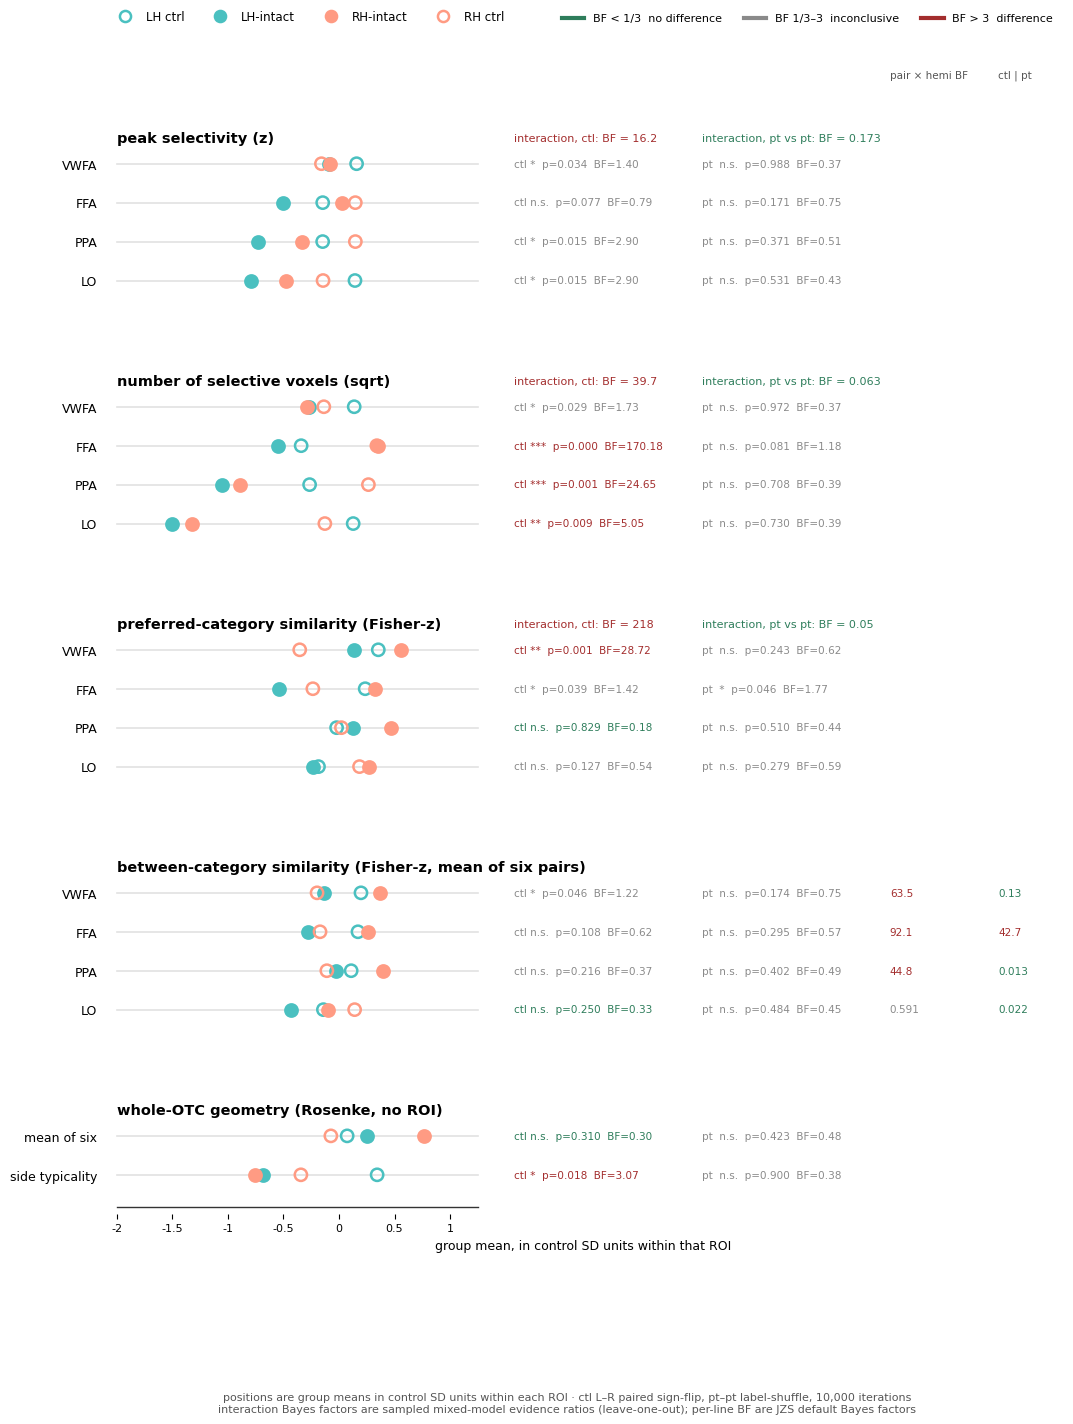

saved /user_data/csimmon2/git_repos/sym_pt/C_results/figures/whole_otc_bayes/per_roi_lines_z.png


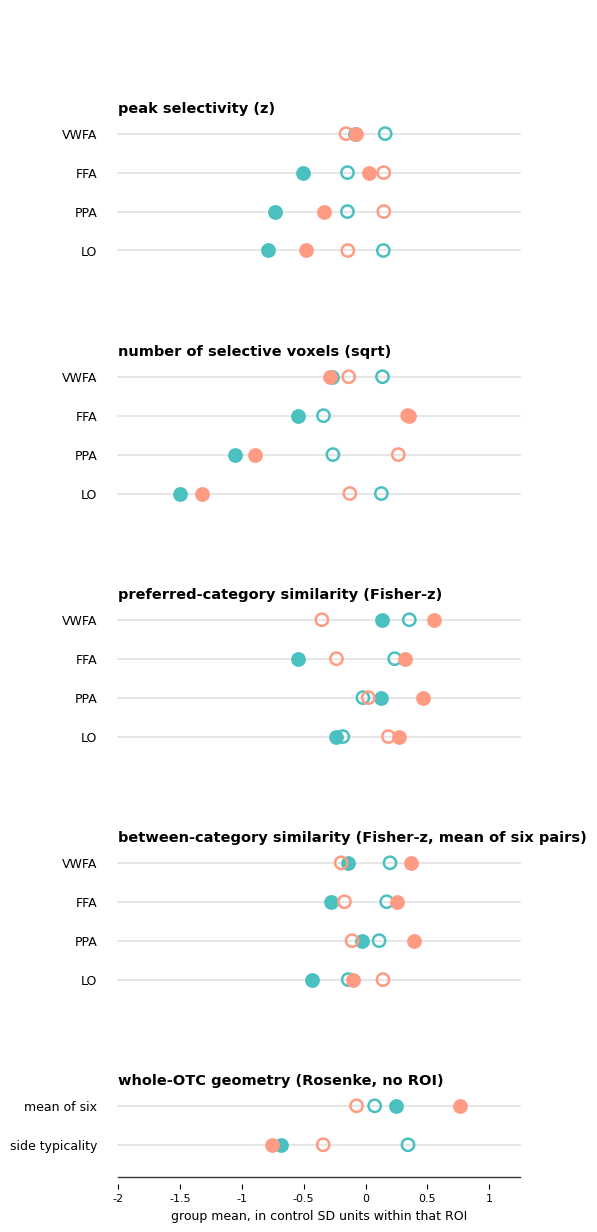

saved /user_data/csimmon2/git_repos/sym_pt/C_results/figures/whole_otc_bayes/per_roi_lines_z_bare.png


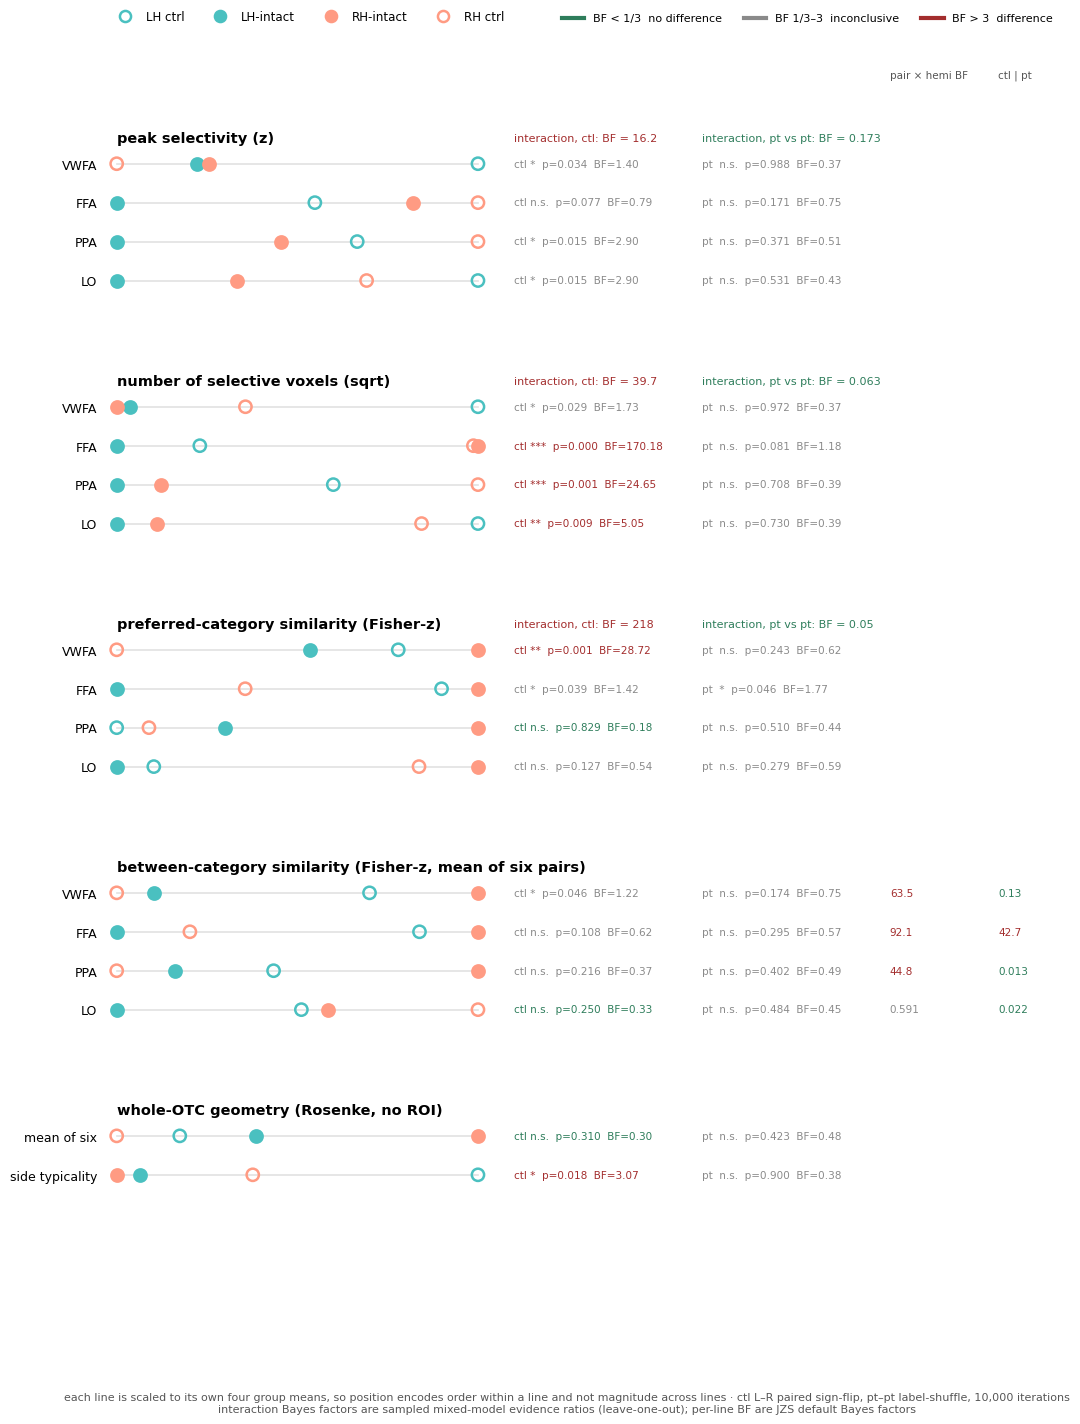

saved /user_data/csimmon2/git_repos/sym_pt/C_results/figures/whole_otc_bayes/per_roi_lines_minmax.png


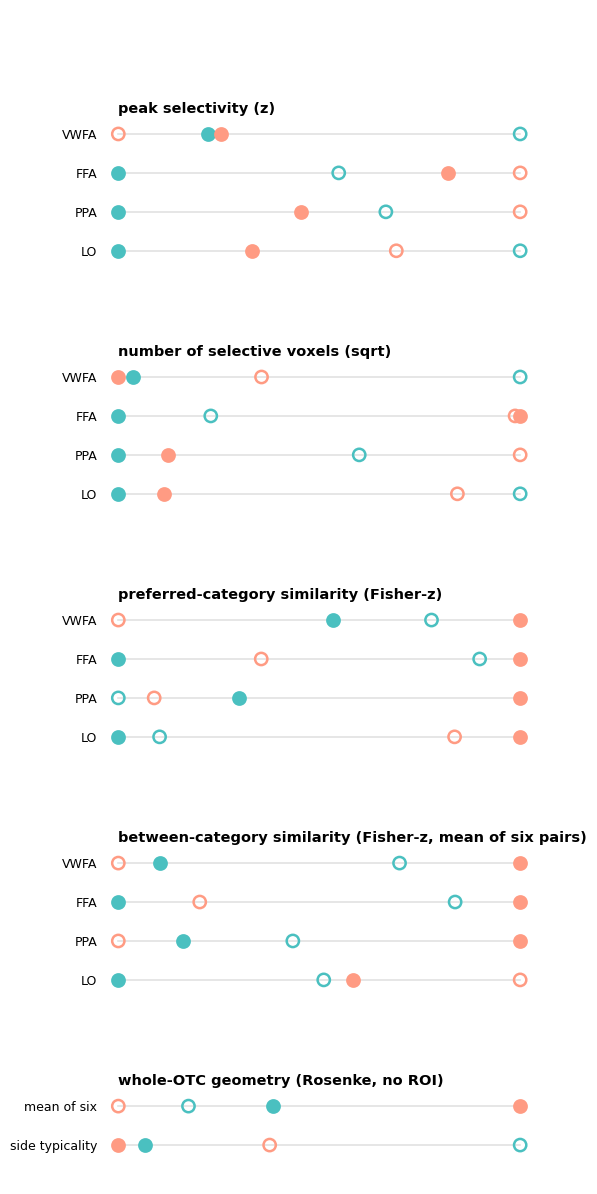

saved /user_data/csimmon2/git_repos/sym_pt/C_results/figures/whole_otc_bayes/per_roi_lines_minmax_bare.png


In [10]:
# ─── Per-ROI measure lines: four groups, one short axis per ROI ─────────────
# Needs from final_figures.ipynb: peak_c, peak_p, vox_c, vox_p, rsa_c_long,
# rsa_p_long, pk_c, pk_p, FIG_DIR, np, pd, plt.
# Needs bf10_jzs from the Bayes-factor cell.
#
# One block per measure; inside a block, one short line per ROI on its own axis.
# Nothing is pooled across ROIs, so control left-right differences that run in
# opposite directions across ROIs are preserved rather than cancelled.
#
# Positions are group means of the raw measure, in that measure's own units.
# Each line is scaled to its own range, so positions are comparable WITHIN a
# line and not across lines; the axis is therefore unlabelled and the numbers
# are printed to stdout for the legend or a supplementary table.
#
# Brackets, all computed from the same per-ROI values as the positions:
#   ctl L vs ctl R    paired, sign-flip permutation
#   pt L vs pt R      unpaired, label-shuffle permutation
# with the JZS BF10 alongside, so a null reads as evidence for or against.

ROIS_23 = ['word_VWFA', 'face_FFA', 'house_PPA_strict', 'object_LOC']
ROI_TT = {'word_VWFA': 'VWFA', 'face_FFA': 'FFA',
          'house_PPA_strict': 'PPA', 'object_LOC': 'LO'}
NPERM_23 = 10000
rng23 = np.random.default_rng(19)
COL23 = {'ctl_L': '#4ac0c0', 'pt_L': '#4ac0c0',      # left  = teal
         'pt_R': '#ff9b83', 'ctl_R': '#ff9b83'}      # right = peach
# controls open, patients filled, both in their side's colour
# Bracket text is coloured by the Bayes factor, not by p:
#   BF < 1/3  evidence for no difference     BF 1/3-3  inconclusive
#   BF > 3    evidence for a difference
BF_COL = {'null': '#2e7d5b', 'incon': '#8a8a8a', 'diff': '#a32d2d'}

# Interaction Bayes factors for the patient-versus-patient comparison, from the
# sampled mixed models (bambi/PyMC, subject random intercept). These are where
# evidence FOR the null lives: a two-group t test at n = 12 has a BF floor near
# 0.3, so the per-line contrasts can only ever read as inconclusive, whereas the
# interaction pools across the four categories or the six pairs.
# Strictly these are leave-one-out evidence ratios, not marginal-likelihood BFs.
INTERACTION_BF = {
    'peak selectivity (z)': 0.173,
    'number of selective voxels (sqrt)': 0.063,
    'preferred-category similarity (Fisher-z)': 0.050,
}
PAIR_BF_BY_ROI = {'word_VWFA': 0.130, 'face_FFA': 42.7,
                  'house_PPA_strict': 0.013, 'object_LOC': 0.022}

# Control left-versus-right interactions, same sampled quantity. Fill from
# cell24 output; left as None the figure omits them rather than inventing them.
CONTROL_INTERACTION_BF = {
    'peak selectivity (z)': 16.2,
    'number of selective voxels (sqrt)': 39.7,
    'preferred-category similarity (Fisher-z)': 218.0,
}
CTRL_PAIR_BF_BY_ROI = {'word_VWFA': 63.5, 'face_FFA': 92.1,
                       'house_PPA_strict': 44.8, 'object_LOC': 0.591}


def _bfc(bf):
    return BF_COL['null'] if bf < 1 / 3 else \
        BF_COL['diff'] if bf > 3 else BF_COL['incon']
LBL23 = {'ctl_L': 'LH ctrl', 'pt_L': 'LH-intact',
         'pt_R': 'RH-intact', 'ctl_R': 'RH ctrl'}
SIG = '#a32d2d'


def _vals(cdf, pdf, col, roi):
    """Per-subject values for the four groups at one ROI."""
    def g(d, hemi, intact=None):
        m = (d['category'] == roi) & (d['hemi'] == hemi)
        if intact is not None:
            m &= (d['intact_hemi'] == intact)
        return (d.loc[m].groupby('subject_id')[col].mean())
    return {'ctl_L': g(cdf, 'l'), 'ctl_R': g(cdf, 'r'),
            'pt_L': g(pdf, 'l', 'left'), 'pt_R': g(pdf, 'r', 'right')}


def _test23(a, b, paired):
    a, b = np.asarray(a, float), np.asarray(b, float)
    if paired:
        d = a - b
        obs = d.mean()
        k = sum(abs((d * rng23.choice([-1, 1], len(d))).mean()) >= abs(obs) - 1e-12
                for _ in range(NPERM_23))
        return (k + 1) / (NPERM_23 + 1), bf10_jzs(a, b, paired=True)
    obs = a.mean() - b.mean()
    pool, na, k = np.concatenate([a, b]), len(a), 0
    for _ in range(NPERM_23):
        p = rng23.permutation(pool)
        if abs(p[:na].mean() - p[na:].mean()) >= abs(obs) - 1e-12:
            k += 1
    return (k + 1) / (NPERM_23 + 1), bf10_jzs(a, b)


def _stars(p):
    return '***' if p < .001 else '**' if p < .01 else '*' if p < .05 else 'n.s.'


# peak location is null on every comparison and is reported in the text only
BLOCKS = [
    ('peak selectivity (z)', peak_c, peak_p, 'peak_z', ROIS_23),
    ('number of selective voxels (sqrt)', vox_c, vox_p, 'volume', ROIS_23),
    ('preferred-category similarity (Fisher-z)',
     rsa_c_long.drop_duplicates(['subject_id', 'category', 'hemi']),
     rsa_p_long.drop_duplicates(['subject_id', 'category', 'hemi']),
     'liu_distinctiveness', ROIS_23),
    ('between-category similarity (Fisher-z, mean of six pairs)',
     rsa_c_long, rsa_p_long, 'fisher_r', ROIS_23),
]

# ---- whole-OTC geometry, appended as its own block ------------------------
# Six between-category similarities per hemisphere over the whole OTC parcel
# (Rosenke method, no sphere and no peak-finding). Two lines: the mean of the
# six values (level) and side typicality (whether the geometry is identifiably
# left or right). Requires the whole-OTC per-subject file.
OTC_CSV_23 = REPO / 'H_RosenkeRSM' / 'otc_rsm_persubject.csv'
OTC23 = None
try:
    _o = pd.read_csv(OTC_CSV_23)
    _p6 = [c for c in _o.columns if '-' in c]
    _o['set'] = np.where(
        _o.group == 'control', 'ctl_' + _o.hemi.str.upper(),
        np.where(_o.intact_hemi == _o.hemi.map({'l': 'left', 'r': 'right'}),
                 'pt_' + _o.hemi.str.upper(), 'drop'))
    _o = _o[_o['set'] != 'drop'].reset_index(drop=True)
    _M = _o[_p6].to_numpy(float)
    _Z = (_M - _M.mean(1, keepdims=True)) / _M.std(1, ddof=0, keepdims=True)
    _C = _Z @ _Z.T / len(_p6)
    _same = _o['subject_id'].to_numpy()[:, None] == _o['subject_id'].to_numpy()[None, :]
    _idx = {k: np.where(_o['set'].to_numpy() == k)[0]
            for k in ('ctl_L', 'ctl_R', 'pt_L', 'pt_R')}

    def _agree23(i, js):
        b, keep = _C[np.ix_([i], js)], ~_same[np.ix_([i], js)]
        return b[keep].mean()

    _typ = np.array([
        _agree23(i, _idx['ctl_L' if _o['set'][i].endswith('L') else 'ctl_R'])
        - _agree23(i, _idx['ctl_R' if _o['set'][i].endswith('L') else 'ctl_L'])
        for i in range(len(_o))])
    OTC23 = {}
    for k, ix in _idx.items():
        OTC23[k] = pd.Series(_M[ix].mean(1), index=_o['subject_id'].to_numpy()[ix])
        OTC23[k + '_typ'] = pd.Series(_typ[ix], index=_o['subject_id'].to_numpy()[ix])
    print(f'\nwhole-OTC loaded: ' + '  '.join(
        f'{k} {len(_idx[k])}' for k in ('ctl_L', 'pt_L', 'pt_R', 'ctl_R')))
except Exception as e:
    print('whole-OTC block skipped:', e)

Z_LO, Z_HI = -2.0, 1.4      # shared x range in control SD units
# ---- pass 1: collect positions under BOTH scalings, plus the tests --------
# Two scalings are computed for every line and both are rendered, because they
# answer different questions:
#
#   'z'       group means in control SD units within that ROI. Spacing is
#             comparable across every line and proportional to the real effect.
#             Statistically the defensible one.
#   'minmax'  each line rescaled to its own four group means, leftmost at 0 and
#             rightmost at 1. Reads more cleanly, but position encodes ORDER
#             within a line only - a tiny difference and a large one look the
#             same. Use only with a caption that says so.
#
# Nothing about the tests or the ordering changes between them; z-scoring and
# min-max are both monotone transforms of the same group means.

def _scale(mus, ctl_pair):
    ref = pd.concat(ctl_pair)
    m0, sd0 = ref.mean(), (ref.std(ddof=1) or 1.0)
    z = {k: (m - m0) / sd0 for k, m in mus.items()}
    lo, hi = min(mus.values()), max(mus.values())
    sp = (hi - lo) or 1.0
    mm = {k: (m - lo) / sp for k, m in mus.items()}
    return z, mm


DRAW = []
for title, cdf, pdf, col, rois in BLOCKS:
    lines = []
    for roi in rois:
        v = _vals(cdf, pdf, col, roi)
        mus = {k: s_.mean() for k, s_ in v.items()}
        z, mm = _scale(mus, (v['ctl_L'], v['ctl_R']))
        common = v['ctl_L'].index.intersection(v['ctl_R'].index)
        pc, bc = _test23(v['ctl_L'][common].to_numpy(),
                         v['ctl_R'][common].to_numpy(), True)
        pp, bp = _test23(v['pt_L'].to_numpy(), v['pt_R'].to_numpy(), False)
        lines.append((ROI_TT.get(roi, roi), roi, z, mm, mus, pc, bc, pp, bp))
    DRAW.append((title, lines))

if OTC23:
    lines = []
    for suffix, name in (('', 'mean of six'), ('_typ', 'side typicality')):
        v = {k: OTC23[k + suffix] for k in ('ctl_L', 'pt_L', 'pt_R', 'ctl_R')}
        mus = {k: s_.mean() for k, s_ in v.items()}
        z, mm = _scale(mus, (v['ctl_L'], v['ctl_R']))
        common = v['ctl_L'].index.intersection(v['ctl_R'].index)
        pc, bc = _test23(v['ctl_L'][common].to_numpy(),
                         v['ctl_R'][common].to_numpy(), True)
        pp, bp = _test23(v['pt_L'].to_numpy(), v['pt_R'].to_numpy(), False)
        lines.append((name, None, z, mm, mus, pc, bc, pp, bp))
    DRAW.append(('whole-OTC geometry (Rosenke, no ROI)', lines))

_allz = [x for _, ls in DRAW for (_, _, z, *_r) in ls for x in z.values()]
Z_RANGE = (np.floor(min(_allz) * 4) / 4 - 0.25,
           np.ceil(max(_allz) * 4) / 4 + 0.25)
print(f'z range in control SD units: {Z_RANGE[0]:g} to {Z_RANGE[1]:g}')

# printed values are scaling-independent
for title, lines in DRAW:
    print(f'\n{title}')
    for name, roi, z, mm, mus, pc, bc, pp, bp in lines:
        print(f'  {name:16s} ' + '  '.join(f'{LBL23[k]} {mus[k]:+.3f}'
              for k in ('ctl_L', 'pt_L', 'pt_R', 'ctl_R'))
              + f'   ctl p={pc:.4f} BF={bc:.2f} | pt p={pp:.4f} BF={bp:.2f}')


def _render(scale, annotate, fname):
    LO, HI = Z_RANGE if scale == 'z' else (0.0, 1.0)
    SPAN = HI - LO
    C1, C2, C3 = HI + .10 * SPAN, HI + .62 * SPAN, HI + 1.14 * SPAN
    X_MAX = HI + 1.62 * SPAN
    pick = 2 if scale == 'z' else 3

    nrow = sum(len(ls) for _, ls in DRAW)
    w = 12.4 if annotate else 5.6
    fig, ax = plt.subplots(figsize=(w, 0.50 * nrow + 1.05 * len(DRAW) + 1.0))
    y, yticks, ylabels = 0.0, [], []

    for title, lines in DRAW:
        y -= 1.30
        ax.text(LO, y + .38, title, fontsize=10.5, fontweight='bold',
                ha='left', va='center')
        if annotate:
            bci = CONTROL_INTERACTION_BF.get(title)
            bpi = INTERACTION_BF.get(title)
            if bci is not None:
                ax.text(C1, y + .38, f'interaction, ctl: BF = {bci:.3g}',
                        fontsize=8, color=_bfc(bci), va='center')
            if bpi is not None:
                ax.text(C2, y + .38, f'interaction, pt vs pt: BF = {bpi:.3g}',
                        fontsize=8, color=_bfc(bpi), va='center')

        for row in lines:
            name, roi, pc, bc, pp, bp = row[0], row[1], row[5], row[6], row[7], row[8]
            xs = row[pick]
            ax.plot([LO, HI], [y, y], color='#e2e2e2', lw=1.2, zorder=1)
            for k in ('ctl_L', 'pt_L', 'pt_R', 'ctl_R'):
                pt = k.startswith('pt')
                ax.scatter([xs[k]], [y], s=78,
                           facecolor=COL23[k] if pt else 'none',
                           edgecolor=COL23[k], linewidth=1.8, zorder=3)
            if annotate:
                ax.text(C1, y, f'ctl {_stars(pc)}  p={pc:.3f}  BF={bc:.2f}',
                        va='center', fontsize=7.5, color=_bfc(bc))
                ax.text(C2, y, f'pt  {_stars(pp)}  p={pp:.3f}  BF={bp:.2f}',
                        va='center', fontsize=7.5, color=_bfc(bp))
                if roi is not None and title.startswith('between-category'):
                    for xcol, d in ((C3, CTRL_PAIR_BF_BY_ROI),
                                    (C3 + .30 * SPAN, PAIR_BF_BY_ROI)):
                        b = d.get(roi)
                        if b is not None:
                            ax.text(xcol, y, f'{b:.3g}', va='center',
                                    fontsize=7.5, color=_bfc(b))
            yticks.append(y); ylabels.append(name)
            y -= 0.58

    if annotate and any(t.startswith('between-category') for t, _ in DRAW):
        ax.text(C3, 0.02, 'pair \u00d7 hemi BF', fontsize=7.5, color='#555',
                va='center')
        ax.text(C3 + .30 * SPAN, 0.02, 'ctl | pt', fontsize=7.5, color='#555',
                va='center')

    ax.set_yticks(yticks); ax.set_yticklabels(ylabels, fontsize=9)
    if scale == 'z':
        ticks = np.arange(LO, HI + .001, 0.5)
        ax.set_xticks(ticks)
        ax.set_xticklabels([f'{t:g}' for t in ticks], fontsize=8)
        ax.plot([LO, HI], [y + .10, y + .10], color='#333', lw=1,
                clip_on=False, zorder=4)
        ax.set_xlabel('group mean, in control SD units within that ROI',
                      fontsize=9)
    else:
        ax.set_xticks([])
    ax.set_xlim(LO - .04 * SPAN, X_MAX if annotate else HI + .04 * SPAN)
    ax.set_ylim(y, 0.55)
    for sp in ('top', 'right', 'left', 'bottom'):
        ax.spines[sp].set_visible(False)
    ax.tick_params(axis='y', length=0)

    h = [plt.Line2D([], [], marker='o', ls='',
                    mfc=COL23[k] if k.startswith('pt') else 'none',
                    mec=COL23[k], mew=1.8, ms=8, label=LBL23[k])
         for k in ('ctl_L', 'pt_L', 'pt_R', 'ctl_R')]
    leg1 = ax.legend(handles=h, fontsize=8.5, frameon=False, ncol=4,
                     loc='lower left', bbox_to_anchor=(0, 1.005))
    ax.add_artist(leg1)
    if annotate:
        hb = [plt.Line2D([], [], ls='-', lw=3, color=BF_COL[k], label=l)
              for k, l in (('null', 'BF < 1/3  no difference'),
                           ('incon', 'BF 1/3\u20133  inconclusive'),
                           ('diff', 'BF > 3  difference'))]
        ax.legend(handles=hb, fontsize=8, frameon=False, ncol=3,
                  loc='lower right', bbox_to_anchor=(1, 1.005))
        cap = ('positions are group means in control SD units within each ROI'
               if scale == 'z' else
               'each line is scaled to its own four group means, so position '
               'encodes order within a line and not magnitude across lines')
        fig.text(0.5, -0.02,
                 cap + ' \u00b7 ctl L\u2013R paired sign-flip, pt\u2013pt '
                 'label-shuffle, 10,000 iterations\ninteraction Bayes factors '
                 'are sampled mixed-model evidence ratios (leave-one-out); '
                 'per-line BF are JZS default Bayes factors',
                 ha='center', fontsize=8, color='#555')

    out = FIG_DIR / fname
    plt.savefig(out, dpi=300, bbox_inches='tight')
    plt.show()
    print('saved', out)


for _scale in ('z', 'minmax'):
    _render(_scale, True, f'per_roi_lines_{_scale}.png')
    _render(_scale, False, f'per_roi_lines_{_scale}_bare.png')



whole-OTC loaded: ctl_L 36  pt_L 12  pt_R 12  ctl_R 36


z range in control SD units: -2 to 1.25

peak selectivity (z)
  VWFA             LH ctrl +5.439  LH-intact +5.072  RH-intact +5.087  RH ctrl +4.967   ctl p=0.0345 BF=1.40 | pt p=0.9879 BF=0.37
  FFA              LH ctrl +10.068  LH-intact +8.620  RH-intact +10.788  RH ctrl +11.261   ctl p=0.0767 BF=0.79 | pt p=0.1715 BF=0.75
  PPA              LH ctrl +7.485  LH-intact +5.903  RH-intact +6.982  RH ctrl +8.279   ctl p=0.0151 BF=2.90 | pt p=0.3711 BF=0.51
  LO               LH ctrl +12.860  LH-intact +10.025  RH-intact +10.968  RH ctrl +11.986   ctl p=0.0151 BF=2.90 | pt p=0.5308 BF=0.43

number of selective voxels (sqrt)
  VWFA             LH ctrl +30.767  LH-intact +24.444  RH-intact +24.202  RH ctrl +26.542   ctl p=0.0292 BF=1.73 | pt p=0.9716 BF=0.37
  FFA              LH ctrl +26.169  LH-intact +23.904  RH-intact +33.745  RH ctrl +33.621   ctl p=0.0003 BF=170.18 | pt p=0.0814 BF=1.18
  PPA              LH ctrl +22.965  LH-intact +17.389  RH-intact +18.537  RH ctrl +26.689   ctl p=0.

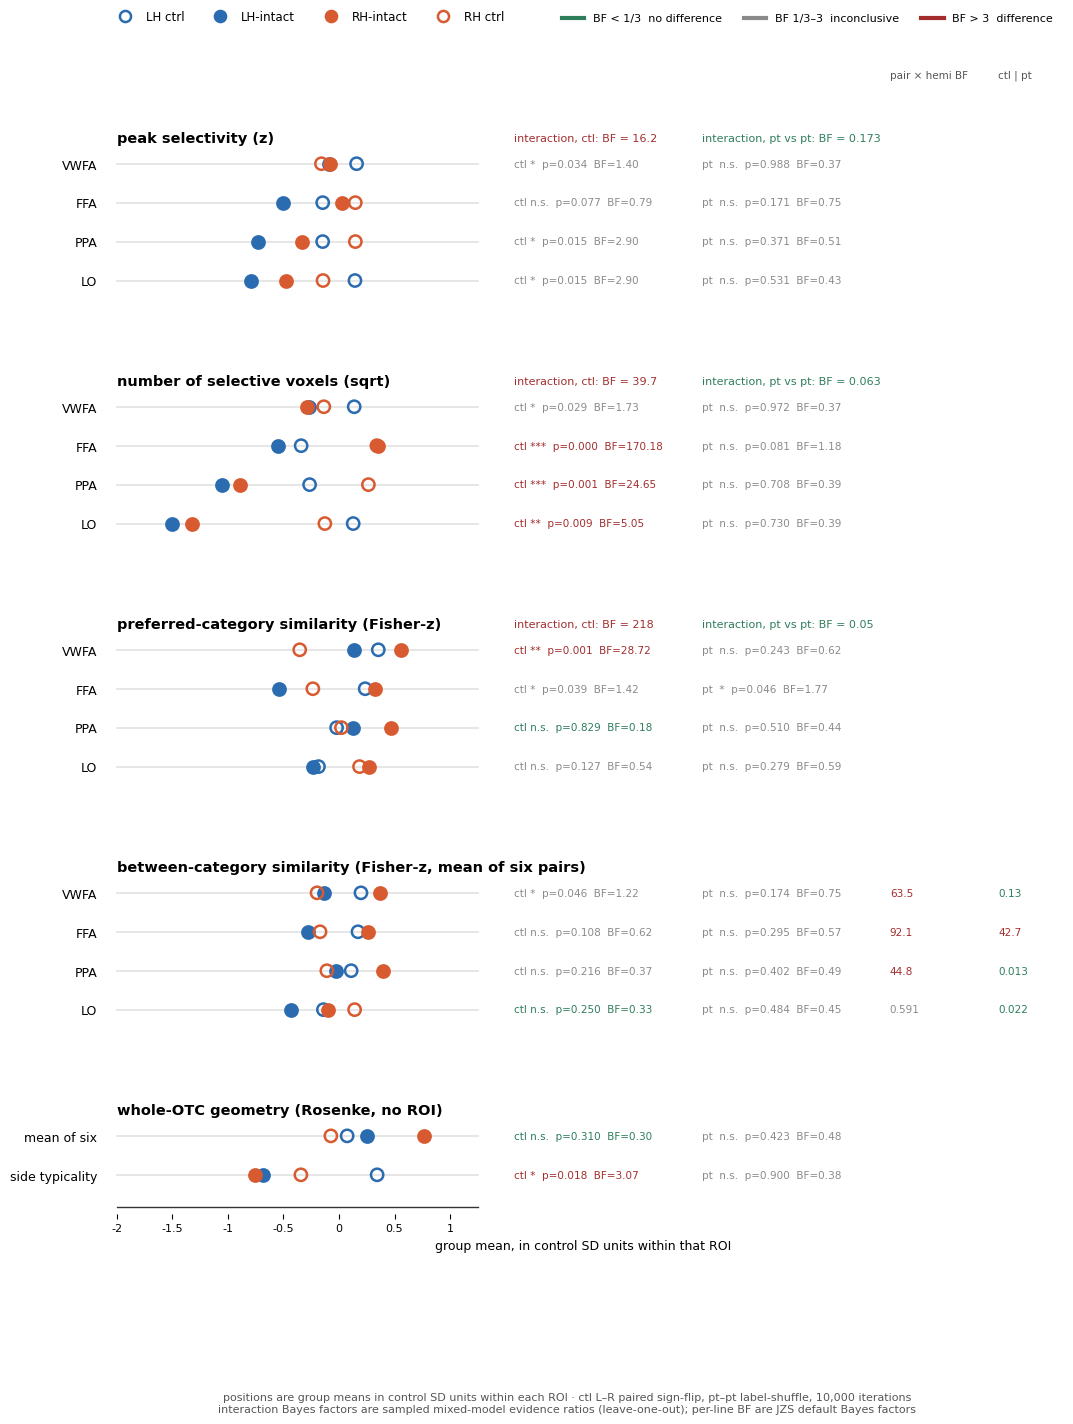

saved /user_data/csimmon2/git_repos/sym_pt/C_results/figures/whole_otc_bayes/per_roi_lines_z.png


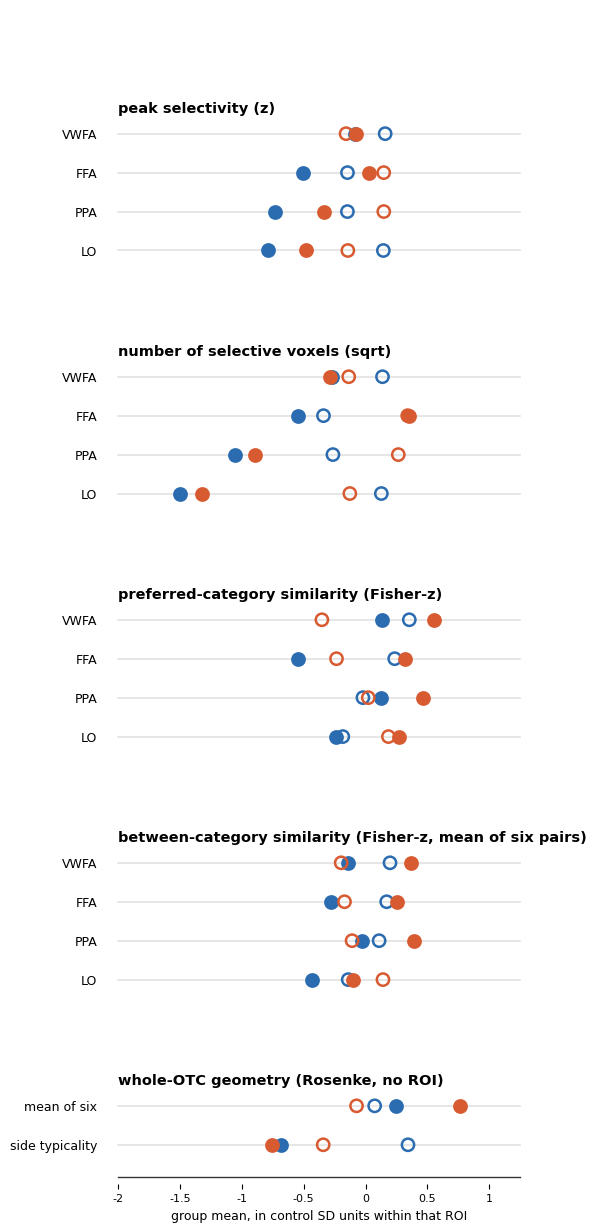

saved /user_data/csimmon2/git_repos/sym_pt/C_results/figures/whole_otc_bayes/per_roi_lines_z_bare.png


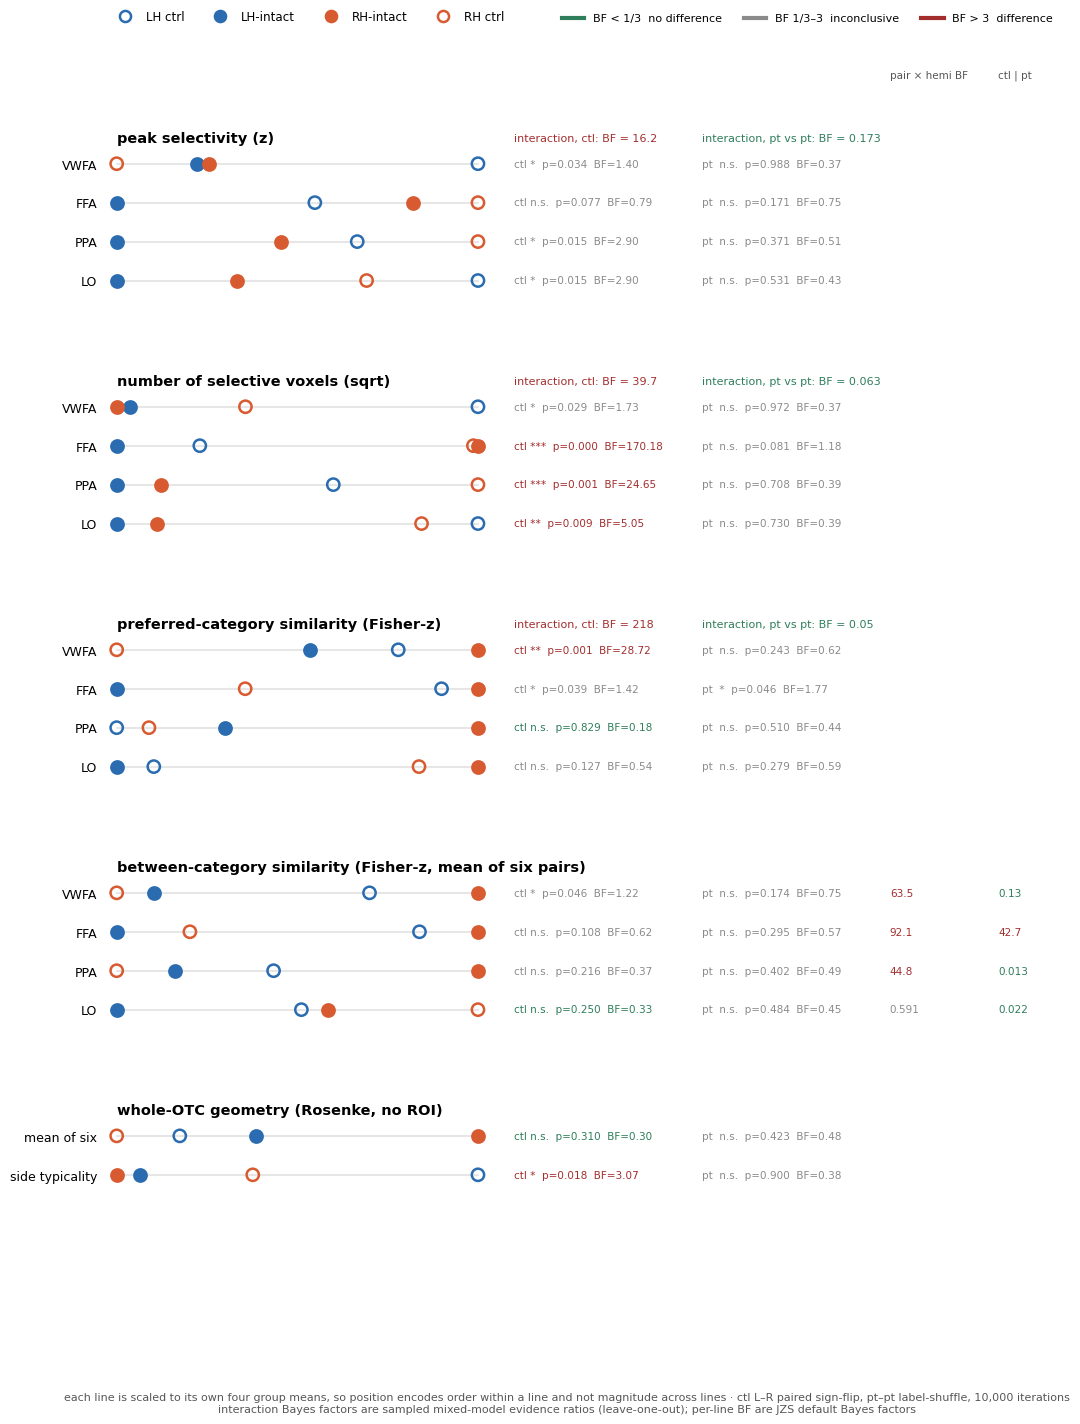

saved /user_data/csimmon2/git_repos/sym_pt/C_results/figures/whole_otc_bayes/per_roi_lines_minmax.png


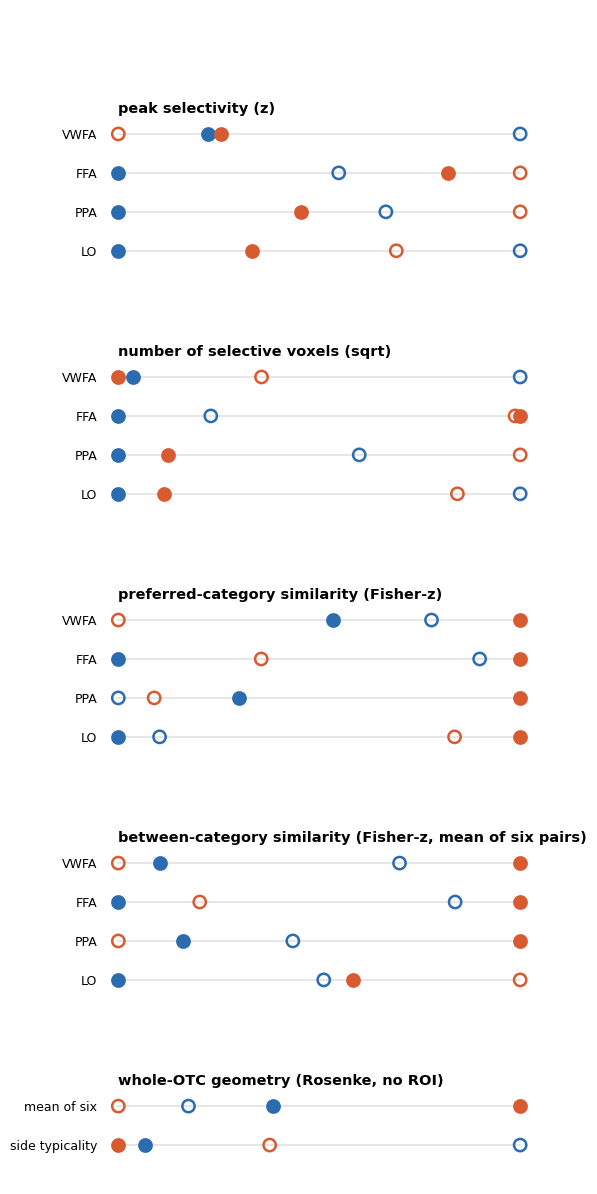

saved /user_data/csimmon2/git_repos/sym_pt/C_results/figures/whole_otc_bayes/per_roi_lines_minmax_bare.png


In [18]:
# ─── Per-ROI measure lines: four groups, one short axis per ROI ─────────────
# Needs from final_figures.ipynb: peak_c, peak_p, vox_c, vox_p, rsa_c_long,
# rsa_p_long, pk_c, pk_p, FIG_DIR, np, pd, plt.
# Needs bf10_jzs from the Bayes-factor cell.

ROIS_23 = ['word_VWFA', 'face_FFA', 'house_PPA_strict', 'object_LOC']
ROI_TT = {'word_VWFA': 'VWFA', 'face_FFA': 'FFA',
          'house_PPA_strict': 'PPA', 'object_LOC': 'LO'}
NPERM_23 = 10000
rng23 = np.random.default_rng(19)

# ─── COLOR PALETTE (Directly from Figure 1 Variables) ───────────────────────
# Left  = C_SCAN (#2B6CB0, Steel Blue)
# Right = C_SURG (#D85A30, Terracotta Orange)
C_SCAN = '#2B6CB0'
C_SURG = '#D85A30'

COL23 = {'ctl_L': C_SCAN, 'pt_L': C_SCAN,      # Left  = Steel Blue
         'ctl_R': C_SURG, 'pt_R': C_SURG}      # Right = Terracotta Orange
# Controls open circles, patients filled circles, both in their hemisphere's color.

BF_COL = {'null': '#2e7d5b', 'incon': '#8a8a8a', 'diff': '#a32d2d'}

INTERACTION_BF = {
    'peak selectivity (z)': 0.173,
    'number of selective voxels (sqrt)': 0.063,
    'preferred-category similarity (Fisher-z)': 0.050,
}
PAIR_BF_BY_ROI = {'word_VWFA': 0.130, 'face_FFA': 42.7,
                  'house_PPA_strict': 0.013, 'object_LOC': 0.022}

CONTROL_INTERACTION_BF = {
    'peak selectivity (z)': 16.2,
    'number of selective voxels (sqrt)': 39.7,
    'preferred-category similarity (Fisher-z)': 218.0,
}
CTRL_PAIR_BF_BY_ROI = {'word_VWFA': 63.5, 'face_FFA': 92.1,
                       'house_PPA_strict': 44.8, 'object_LOC': 0.591}


def _bfc(bf):
    return BF_COL['null'] if bf < 1 / 3 else \
        BF_COL['diff'] if bf > 3 else BF_COL['incon']

LBL23 = {'ctl_L': 'LH ctrl', 'pt_L': 'LH-intact',
         'pt_R': 'RH-intact', 'ctl_R': 'RH ctrl'}
SIG = '#a32d2d'


def _vals(cdf, pdf, col, roi):
    """Per-subject values for the four groups at one ROI."""
    def g(d, hemi, intact=None):
        m = (d['category'] == roi) & (d['hemi'] == hemi)
        if intact is not None:
            m &= (d['intact_hemi'] == intact)
        return (d.loc[m].groupby('subject_id')[col].mean())
    return {'ctl_L': g(cdf, 'l'), 'ctl_R': g(cdf, 'r'),
            'pt_L': g(pdf, 'l', 'left'), 'pt_R': g(pdf, 'r', 'right')}


def _test23(a, b, paired):
    a, b = np.asarray(a, float), np.asarray(b, float)
    if paired:
        d = a - b
        obs = d.mean()
        k = sum(abs((d * rng23.choice([-1, 1], len(d))).mean()) >= abs(obs) - 1e-12
                for _ in range(NPERM_23))
        return (k + 1) / (NPERM_23 + 1), bf10_jzs(a, b, paired=True)
    obs = a.mean() - b.mean()
    pool, na, k = np.concatenate([a, b]), len(a), 0
    for _ in range(NPERM_23):
        p = rng23.permutation(pool)
        if abs(p[:na].mean() - p[na:].mean()) >= abs(obs) - 1e-12:
            k += 1
    return (k + 1) / (NPERM_23 + 1), bf10_jzs(a, b)


def _stars(p):
    return '***' if p < .001 else '**' if p < .01 else '*' if p < .05 else 'n.s.'


BLOCKS = [
    ('peak selectivity (z)', peak_c, peak_p, 'peak_z', ROIS_23),
    ('number of selective voxels (sqrt)', vox_c, vox_p, 'volume', ROIS_23),
    ('preferred-category similarity (Fisher-z)',
     rsa_c_long.drop_duplicates(['subject_id', 'category', 'hemi']),
     rsa_p_long.drop_duplicates(['subject_id', 'category', 'hemi']),
     'liu_distinctiveness', ROIS_23),
    ('between-category similarity (Fisher-z, mean of six pairs)',
     rsa_c_long, rsa_p_long, 'fisher_r', ROIS_23),
]

# ---- whole-OTC geometry, appended as its own block ------------------------
OTC_CSV_23 = REPO / 'H_RosenkeRSM' / 'otc_rsm_persubject.csv'
OTC23 = None
try:
    _o = pd.read_csv(OTC_CSV_23)
    _p6 = [c for c in _o.columns if '-' in c]
    _o['set'] = np.where(
        _o.group == 'control', 'ctl_' + _o.hemi.str.upper(),
        np.where(_o.intact_hemi == _o.hemi.map({'l': 'left', 'r': 'right'}),
                 'pt_' + _o.hemi.str.upper(), 'drop'))
    _o = _o[_o['set'] != 'drop'].reset_index(drop=True)
    _M = _o[_p6].to_numpy(float)
    _Z = (_M - _M.mean(1, keepdims=True)) / _M.std(1, ddof=0, keepdims=True)
    _C = _Z @ _Z.T / len(_p6)
    _same = _o['subject_id'].to_numpy()[:, None] == _o['subject_id'].to_numpy()[None, :]
    _idx = {k: np.where(_o['set'].to_numpy() == k)[0]
            for k in ('ctl_L', 'ctl_R', 'pt_L', 'pt_R')}

    def _agree23(i, js):
        b, keep = _C[np.ix_([i], js)], ~_same[np.ix_([i], js)]
        return b[keep].mean()

    _typ = np.array([
        _agree23(i, _idx['ctl_L' if _o['set'][i].endswith('L') else 'ctl_R'])
        - _agree23(i, _idx['ctl_R' if _o['set'][i].endswith('L') else 'ctl_L'])
        for i in range(len(_o))])
    OTC23 = {}
    for k, ix in _idx.items():
        OTC23[k] = pd.Series(_M[ix].mean(1), index=_o['subject_id'].to_numpy()[ix])
        OTC23[k + '_typ'] = pd.Series(_typ[ix], index=_o['subject_id'].to_numpy()[ix])
    print(f'\nwhole-OTC loaded: ' + '  '.join(
        f'{k} {len(_idx[k])}' for k in ('ctl_L', 'pt_L', 'pt_R', 'ctl_R')))
except Exception as e:
    print('whole-OTC block skipped:', e)

Z_LO, Z_HI = -2.0, 1.4


def _scale(mus, ctl_pair):
    ref = pd.concat(ctl_pair)
    m0, sd0 = ref.mean(), (ref.std(ddof=1) or 1.0)
    z = {k: (m - m0) / sd0 for k, m in mus.items()}
    lo, hi = min(mus.values()), max(mus.values())
    sp = (hi - lo) or 1.0
    mm = {k: (m - lo) / sp for k, m in mus.items()}
    return z, mm


DRAW = []
for title, cdf, pdf, col, rois in BLOCKS:
    lines = []
    for roi in rois:
        v = _vals(cdf, pdf, col, roi)
        mus = {k: s_.mean() for k, s_ in v.items()}
        z, mm = _scale(mus, (v['ctl_L'], v['ctl_R']))
        common = v['ctl_L'].index.intersection(v['ctl_R'].index)
        pc, bc = _test23(v['ctl_L'][common].to_numpy(),
                         v['ctl_R'][common].to_numpy(), True)
        pp, bp = _test23(v['pt_L'].to_numpy(), v['pt_R'].to_numpy(), False)
        lines.append((ROI_TT.get(roi, roi), roi, z, mm, mus, pc, bc, pp, bp))
    DRAW.append((title, lines))

if OTC23:
    lines = []
    for suffix, name in (('', 'mean of six'), ('_typ', 'side typicality')):
        v = {k: OTC23[k + suffix] for k in ('ctl_L', 'pt_L', 'pt_R', 'ctl_R')}
        mus = {k: s_.mean() for k, s_ in v.items()}
        z, mm = _scale(mus, (v['ctl_L'], v['ctl_R']))
        common = v['ctl_L'].index.intersection(v['ctl_R'].index)
        pc, bc = _test23(v['ctl_L'][common].to_numpy(),
                         v['ctl_R'][common].to_numpy(), True)
        pp, bp = _test23(v['pt_L'].to_numpy(), v['pt_R'].to_numpy(), False)
        lines.append((name, None, z, mm, mus, pc, bc, pp, bp))
    DRAW.append(('whole-OTC geometry (Rosenke, no ROI)', lines))

_allz = [x for _, ls in DRAW for (_, _, z, *_r) in ls for x in z.values()]
Z_RANGE = (np.floor(min(_allz) * 4) / 4 - 0.25,
           np.ceil(max(_allz) * 4) / 4 + 0.25)
print(f'z range in control SD units: {Z_RANGE[0]:g} to {Z_RANGE[1]:g}')

for title, lines in DRAW:
    print(f'\n{title}')
    for name, roi, z, mm, mus, pc, bc, pp, bp in lines:
        print(f'  {name:16s} ' + '  '.join(f'{LBL23[k]} {mus[k]:+.3f}'
              for k in ('ctl_L', 'pt_L', 'pt_R', 'ctl_R'))
              + f'   ctl p={pc:.4f} BF={bc:.2f} | pt p={pp:.4f} BF={bp:.2f}')


def _render(scale, annotate, fname):
    LO, HI = Z_RANGE if scale == 'z' else (0.0, 1.0)
    SPAN = HI - LO
    C1, C2, C3 = HI + .10 * SPAN, HI + .62 * SPAN, HI + 1.14 * SPAN
    X_MAX = HI + 1.62 * SPAN
    pick = 2 if scale == 'z' else 3

    nrow = sum(len(ls) for _, ls in DRAW)
    w = 12.4 if annotate else 5.6
    fig, ax = plt.subplots(figsize=(w, 0.50 * nrow + 1.05 * len(DRAW) + 1.0))
    y, yticks, ylabels = 0.0, [], []

    for title, lines in DRAW:
        y -= 1.30
        ax.text(LO, y + .38, title, fontsize=10.5, fontweight='bold',
                ha='left', va='center')
        if annotate:
            bci = CONTROL_INTERACTION_BF.get(title)
            bpi = INTERACTION_BF.get(title)
            if bci is not None:
                ax.text(C1, y + .38, f'interaction, ctl: BF = {bci:.3g}',
                        fontsize=8, color=_bfc(bci), va='center')
            if bpi is not None:
                ax.text(C2, y + .38, f'interaction, pt vs pt: BF = {bpi:.3g}',
                        fontsize=8, color=_bfc(bpi), va='center')

        for row in lines:
            name, roi, pc, bc, pp, bp = row[0], row[1], row[5], row[6], row[7], row[8]
            xs = row[pick]
            ax.plot([LO, HI], [y, y], color='#e2e2e2', lw=1.2, zorder=1)
            for k in ('ctl_L', 'pt_L', 'pt_R', 'ctl_R'):
                pt = k.startswith('pt')
                ax.scatter([xs[k]], [y], s=78,
                           facecolor=COL23[k] if pt else 'none',
                           edgecolor=COL23[k], linewidth=1.8, zorder=3)
            if annotate:
                ax.text(C1, y, f'ctl {_stars(pc)}  p={pc:.3f}  BF={bc:.2f}',
                        va='center', fontsize=7.5, color=_bfc(bc))
                ax.text(C2, y, f'pt  {_stars(pp)}  p={pp:.3f}  BF={bp:.2f}',
                        va='center', fontsize=7.5, color=_bfc(bp))
                if roi is not None and title.startswith('between-category'):
                    for xcol, d in ((C3, CTRL_PAIR_BF_BY_ROI),
                                    (C3 + .30 * SPAN, PAIR_BF_BY_ROI)):
                        b = d.get(roi)
                        if b is not None:
                            ax.text(xcol, y, f'{b:.3g}', va='center',
                                    fontsize=7.5, color=_bfc(b))
            yticks.append(y); ylabels.append(name)
            y -= 0.58

    if annotate and any(t.startswith('between-category') for t, _ in DRAW):
        ax.text(C3, 0.02, 'pair \u00d7 hemi BF', fontsize=7.5, color='#555',
                va='center')
        ax.text(C3 + .30 * SPAN, 0.02, 'ctl | pt', fontsize=7.5, color='#555',
                va='center')

    ax.set_yticks(yticks); ax.set_yticklabels(ylabels, fontsize=9)
    if scale == 'z':
        ticks = np.arange(LO, HI + .001, 0.5)
        ax.set_xticks(ticks)
        ax.set_xticklabels([f'{t:g}' for t in ticks], fontsize=8)
        ax.plot([LO, HI], [y + .10, y + .10], color='#333', lw=1,
                clip_on=False, zorder=4)
        ax.set_xlabel('group mean, in control SD units within that ROI',
                      fontsize=9)
    else:
        ax.set_xticks([])
    ax.set_xlim(LO - .04 * SPAN, X_MAX if annotate else HI + .04 * SPAN)
    ax.set_ylim(y, 0.55)
    for sp in ('top', 'right', 'left', 'bottom'):
        ax.spines[sp].set_visible(False)
    ax.tick_params(axis='y', length=0)

    h = [plt.Line2D([], [], marker='o', ls='',
                    mfc=COL23[k] if k.startswith('pt') else 'none',
                    mec=COL23[k], mew=1.8, ms=8, label=LBL23[k])
         for k in ('ctl_L', 'pt_L', 'pt_R', 'ctl_R')]
    leg1 = ax.legend(handles=h, fontsize=8.5, frameon=False, ncol=4,
                     loc='lower left', bbox_to_anchor=(0, 1.005))
    ax.add_artist(leg1)
    if annotate:
        hb = [plt.Line2D([], [], ls='-', lw=3, color=BF_COL[k], label=l)
              for k, l in (('null', 'BF < 1/3  no difference'),
                           ('incon', 'BF 1/3\u20133  inconclusive'),
                           ('diff', 'BF > 3  difference'))]
        ax.legend(handles=hb, fontsize=8, frameon=False, ncol=3,
                  loc='lower right', bbox_to_anchor=(1, 1.005))
        cap = ('positions are group means in control SD units within each ROI'
               if scale == 'z' else
               'each line is scaled to its own four group means, so position '
               'encodes order within a line and not magnitude across lines')
        fig.text(0.5, -0.02,
                 cap + ' \u00b7 ctl L\u2013R paired sign-flip, pt\u2013pt '
                 'label-shuffle, 10,000 iterations\ninteraction Bayes factors '
                 'are sampled mixed-model evidence ratios (leave-one-out); '
                 'per-line BF are JZS default Bayes factors',
                 ha='center', fontsize=8, color='#555')

    out = FIG_DIR / fname
    plt.savefig(out, dpi=300, bbox_inches='tight')
    plt.show()
    print('saved', out)


for _scale in ('z', 'minmax'):
    _render(_scale, True, f'per_roi_lines_{_scale}.png')
    _render(_scale, False, f'per_roi_lines_{_scale}_bare.png')

In [12]:
# ─── Fill the three [PENDING] values in the whole-OTC section ──────────────
# Run after the whole-OTC geometry cell (needs M_CH, IDX_CH, ch, _zc, _corr,
# _perm1 from it). Prints the three numbers in the form the manuscript needs.
#
#   1  profile shape, controls left versus right   (paired, sign-flip)
#   2  profile shape, patients versus patients     (unpaired, label-shuffle)
#   3  within-group consistency, patients versus patients
#
# Profile shape: the six between-set mean differences are centred on their own
# average and summed as squares, so an overall level difference does not
# register as a difference in shape.
# Consistency: each subject's six values correlated against every other member
# of their own set and averaged, then the two patient sets compared.

NPERM_26 = 10000
rng26 = np.random.default_rng(41)
P6_26 = [c for c in ch.columns if '-' in c]


def _shape_stat(d):
    """Sum of squared mean differences after removing their average."""
    return float(((d - d.mean()) ** 2).sum())


def _profile_shape(sa, sb, paired):
    A, B = M_CH[IDX_CH[sa]], M_CH[IDX_CH[sb]]
    if paired:
        ida = ch['subject_id'].to_numpy()[IDX_CH[sa]]
        idb = ch['subject_id'].to_numpy()[IDX_CH[sb]]
        A, B = A[np.argsort(ida)], B[np.argsort(idb)]
        assert (np.sort(ida) == np.sort(idb)).all(), 'control ids do not match'
        D = A - B
        obs = _shape_stat(D.mean(0))
        null = np.array([
            _shape_stat((D * rng26.choice([-1, 1], len(D))[:, None]).mean(0))
            for _ in range(NPERM_26)])
    else:
        obs = _shape_stat(A.mean(0) - B.mean(0))
        pool, na = np.vstack([A, B]), len(A)
        null = np.empty(NPERM_26)
        for b in range(NPERM_26):
            p = rng26.permutation(len(pool))
            null[b] = _shape_stat(pool[p[:na]].mean(0) - pool[p[na:]].mean(0))
    return obs, (np.sum(null >= obs) + 1) / (NPERM_26 + 1)


def _consistency(idx):
    """Each member's mean correlation to the other members of its own set."""
    Z = _zc(M_CH[idx])
    C = Z @ Z.T / len(P6_26)
    np.fill_diagonal(C, np.nan)
    return np.nanmean(C, axis=1)


print('WHOLE-OTC: the three [PENDING] values')
print('cohort  ' + '  '.join(f'{k} {len(IDX_CH[k])}'
                             for k in ('ctl_L', 'ctl_R', 'pt_L', 'pt_R')))

obs_c, p_c = _profile_shape('ctl_L', 'ctl_R', paired=True)
obs_p, p_p = _profile_shape('pt_L', 'pt_R', paired=False)
print(f'\n1  profile shape, controls L vs R      statistic {obs_c:.4f}  '
      f'p = {p_c:.4f}')
print(f'2  profile shape, patients pt vs pt    statistic {obs_p:.4f}  '
      f'p = {p_p:.4f}')

wl, wr = _consistency(IDX_CH['pt_L']), _consistency(IDX_CH['pt_R'])
d_w, p_w = _perm1(wl, wr)
print(f'3  consistency, patients pt vs pt      {wl.mean():+.3f} vs '
      f'{wr.mean():+.3f}  difference {d_w:+.3f}  p = {p_w:.4f}')

print('\nSENTENCES TO PASTE')
print(f'  controls: "(p = {p_c:.4f}, permutation on profile shape)"')
print(f'  patients: "did not differ ... in the profile of six values '
      f'(p = {p_p:.4f})"')
print(f'  patients: "or in consistency (+{wl.mean():.3f} versus '
      f'+{wr.mean():.3f}, p = {p_w:.4f})"')
print('\nCheck 3 against the values already reported: pt_L consistency should')
print('read +0.419 and pt_R +0.533. If not, the reference set differs from the')
print('one used earlier and the number should not be pasted.')

WHOLE-OTC: the three [PENDING] values
cohort  ctl_L 36  ctl_R 36  pt_L 12  pt_R 12

1  profile shape, controls L vs R      statistic 0.0886  p = 0.0001
2  profile shape, patients pt vs pt    statistic 0.0059  p = 0.9712
3  consistency, patients pt vs pt      +0.419 vs +0.533  difference -0.113  p = 0.1048

SENTENCES TO PASTE
  controls: "(p = 0.0001, permutation on profile shape)"
  patients: "did not differ ... in the profile of six values (p = 0.9712)"
  patients: "or in consistency (+0.419 versus +0.533, p = 0.1048)"

Check 3 against the values already reported: pt_L consistency should
read +0.419 and pt_R +0.533. If not, the reference set differs from the
one used earlier and the number should not be pasted.
